<a href="https://colab.research.google.com/github/EvanTyran/Evan-s-Repository/blob/main/m5_forecasting_comparison_v6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M5 Walmart Sales Forecasting
## CPG Benchmark (Seasonalized Moving Average) vs LightGBM

**Notebook Structure**
- **Cells 1–3**: Shared setup and data loading
- **Cells 4–11**: Model 1 — Seasonalized Moving Average (CPG benchmark)
- **Cells 12–18**: Model 2 — LightGBM (M5 winning approach)
- **Cells 19–21**: Head-to-head comparison

**Dataset**: M5 Forecasting Competition (Walmart Sales)  
**Scope**: CA_1 store, HOBBIES category (565 items)  
**Forecast horizon**: 28 days  
**Validation window**: Last 28 days of dataset (shared across both models)

---
**Architecture note**: Two separate dataframes are maintained throughout:
- `df` — shared base with original string item IDs and seasonal MA columns (never modified after Cell 7)
- `df_lgbm` — LightGBM-specific copy with categorical encoding and lag/rolling features

**Full-scale upgrade**: Remove the filter in Cell 2 to run on all stores/categories. On Kaggle (30GB RAM) or Colab Pro (25GB) this should work without chunking.

---
## SHARED SETUP

### Cell 1: Imports, Drive Mount, Config

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import gc
import zipfile
import os
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

# ── Data path ──────────────────────────────────────────────
DATA_PATH = "/content/drive/MyDrive/Sample Datasets/M5 Forecast Walmart Sales Competition/"

# ── Scope ──────────────────────────────────────────────────
TARGET_STORE    = 'CA_1'
TARGET_CATEGORY = 'HOBBIES'

# ── Shared model config ────────────────────────────────────
PRED_HORIZON    = 28
VALIDATION_DAYS = 28
HOLDOUT_DAYS    = 56

# ── Seasonal MA config ─────────────────────────────────────
CV_THRESHOLD     = 0.5
MIN_YEARS        = 2
MIN_YEAR_DAYS    = 180
INSUFFICIENT_PCT = 0.60
WINDOWS          = [91, 182]

# ── LightGBM config ────────────────────────────────────────
LAG_DAYS        = [7, 14, 28]
ROLLING_WINDOWS = [7, 28]

# ── Plotting style ─────────────────────────────────────────
plt.rcParams['figure.dpi']        = 100
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print('✅ Libraries loaded and Drive mounted.')
print(f'\n📋 Configuration:')
print(f'   Store:          {TARGET_STORE}')
print(f'   Category:       {TARGET_CATEGORY}')
print(f'   Forecast days:  {PRED_HORIZON}')
print(f'   CV threshold:   {CV_THRESHOLD}')
print(f'   MA windows:     {[f"{w//7} weeks" for w in WINDOWS]}')

Mounted at /content/drive
✅ Libraries loaded and Drive mounted.

📋 Configuration:
   Store:          CA_1
   Category:       HOBBIES
   Forecast days:  28
   CV threshold:   0.5
   MA windows:     ['13 weeks', '26 weeks']


### Cell 2: Load and Filter Data

In [ ]:
def load_zip_or_csv(path, filename, **kwargs):
    """Load a file whether it is zipped or plain CSV."""
    full_path = path + filename
    if os.path.exists(full_path + '.zip'):
        with zipfile.ZipFile(full_path + '.zip') as z:
            with z.open(filename) as f:
                return pd.read_csv(f, **kwargs)
    return pd.read_csv(full_path, **kwargs)


print('📂 Loading sales data...')
sales_raw = load_zip_or_csv(DATA_PATH, 'sales_train_validation.csv')
print(f'   Full dataset shape: {sales_raw.shape}')

# Filter BEFORE melting — keeps only target store/category
# To run full scale: remove these two filter conditions
sales_raw = sales_raw[
    (sales_raw['store_id'] == TARGET_STORE) &
    (sales_raw['cat_id']   == TARGET_CATEGORY)
].reset_index(drop=True)
print(f'   After filter shape: {sales_raw.shape}')

print('\n📂 Loading calendar...')
calendar = pd.read_csv(DATA_PATH + 'calendar.csv')
calendar['date'] = pd.to_datetime(calendar['date'])
print(f'   Shape: {calendar.shape}')

print('\n📂 Loading sell prices...')
prices = load_zip_or_csv(DATA_PATH, 'sell_prices.csv')
prices = prices[prices['store_id'] == TARGET_STORE].reset_index(drop=True)
print(f'   Shape (CA_1 only): {prices.shape}')

# Preserve metadata for reference
N_ITEMS       = len(sales_raw)
ITEM_IDS_STR  = sales_raw['item_id'].values   # original string IDs

print(f'\n✅ Data loaded.')
print(f'   Items in scope: {N_ITEMS}')
print(f'   Departments:    {sales_raw["dept_id"].unique()}')
print(f'   Date range:     {calendar["date"].min().date()} → {calendar["date"].max().date()}')

📂 Loading sales data...
   Full dataset shape: (30490, 1919)
   After filter shape: (565, 1919)

📂 Loading calendar...
   Shape: (1969, 14)

📂 Loading sell prices...
   Shape (CA_1 only): (698412, 4)

✅ Data loaded.
   Items in scope: 565
   Departments:    ['HOBBIES_1' 'HOBBIES_2']
   Date range:     2011-01-29 → 2016-06-19


### Cell 3: Melt Wide → Long Format

In [ ]:
id_cols  = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
day_cols = [c for c in sales_raw.columns if c.startswith('d_')]

print(f'📅 Day columns: {len(day_cols)} days (d_1 through {day_cols[-1]})')
print(f'🔄 Melting {N_ITEMS:,} items × {len(day_cols):,} days...')

df = sales_raw.melt(
    id_vars=id_cols,
    value_vars=day_cols,
    var_name='d',
    value_name='sales'
)

# Merge date column
df = df.merge(calendar[['d', 'date']], on='d', how='left')
df['sales'] = df['sales'].astype(np.float32)
df = df.sort_values(['item_id', 'date']).reset_index(drop=True)

# ── Preserve original string item IDs ─────────────────────
# df['item_id'] stays as string throughout — never encoded
# This is critical: seasonal MA profile/window selection
# are keyed by string item IDs
# Only df_lgbm (created in Cell 12) gets categorical encoding
df['item_id_str'] = df['item_id'].copy()

# ── Shared train/validation cutoff ─────────────────────────
# Both models use the same split:
#   Training:   everything up to and including val_cutoff
#   Validation: everything AFTER val_cutoff (last 28 days)
max_date       = df['date'].max()
val_cutoff     = max_date - pd.Timedelta(days=VALIDATION_DAYS)
holdout_cutoff = val_cutoff - pd.Timedelta(days=HOLDOUT_DAYS)

print(f'\n✅ Long format shape: {df.shape}')
print(f'\n📅 Date boundaries:')
print(f'   Full history start:      {df["date"].min().date()}')
print(f'   Holdout period start:    {holdout_cutoff.date()}')
print(f'   Validation period start: {(val_cutoff + pd.Timedelta(days=1)).date()}')
print(f'   Last date (max_date):    {max_date.date()}')
print(f'\n🔍 Preview:')
print(df[['item_id', 'item_id_str', 'date', 'sales']].head(3))

📅 Day columns: 1913 days (d_1 through d_1913)
🔄 Melting 565 items × 1,913 days...

✅ Long format shape: (1080845, 10)

📅 Date boundaries:
   Full history start:      2011-01-29
   Holdout period start:    2016-01-31
   Validation period start: 2016-03-28
   Last date (max_date):    2016-04-24

🔍 Preview:
         item_id    item_id_str       date  sales
0  HOBBIES_1_001  HOBBIES_1_001 2011-01-29    0.0
1  HOBBIES_1_001  HOBBIES_1_001 2011-01-30    0.0
2  HOBBIES_1_001  HOBBIES_1_001 2011-01-31    0.0


---
## MODEL 1: SEASONALIZED MOVING AVERAGE
### CPG Benchmark Methodology

**Approach:**
1. Build combined seasonal indices (DOW × Annual) at multiple aggregation levels
2. Select most granular stable profile per item using CV threshold (0.5)
3. De-seasonalize sales using chosen index
4. Test 13-week vs 26-week MA window per item on holdout period
5. Multiply de-seasonalized baseline × seasonal index to forecast

**Key design decisions:**
- Combined index = Day-of-Week index × Annual calendar day index
- Year-over-year index construction (divide each day by annual mean, average across years)
- Qualifying year: >= 180 days of sales, truncated at last non-zero sale date
- Per-day CV averaged across calendar days as profile stability metric
- Window selection via wMAPE on pre-validation holdout (days -56 to -28 before validation)

### Cell 4: Build Combined Seasonal Indices (DOW × Annual)

In [ ]:
# Training data only — string item IDs preserved in df
train_df = df[df['date'] <= val_cutoff].copy()
train_df['year'] = train_df['date'].dt.year
train_df['doy']  = train_df['date'].dt.dayofyear
train_df['dow']  = train_df['date'].dt.dayofweek

print(f'Training data: {train_df["date"].min().date()} → {train_df["date"].max().date()}')
print(f'Training rows: {len(train_df):,}\n')


def build_dow_index(group_sales, group_dates):
    """Build day-of-week seasonal index for one group."""
    s = pd.Series(group_sales.values,
                  index=pd.to_datetime(group_dates.values), dtype=np.float64)
    nonzero_dates = s[s > 0].index
    if len(nonzero_dates) == 0:
        return {d: 1.0 for d in range(7)}, np.inf
    s = s[:nonzero_dates.max()]
    overall_mean = s.mean()
    if overall_mean == 0:
        return {d: 1.0 for d in range(7)}, np.inf
    dow_means = {}
    for dow in range(7):
        dow_sales = s[s.index.dayofweek == dow]
        dow_means[dow] = dow_sales.mean() if len(dow_sales) > 0 else overall_mean
    dow_index = {dow: mean / overall_mean for dow, mean in dow_means.items()}
    vals   = list(dow_index.values())
    dow_cv = np.std(vals) / np.mean(vals) if np.mean(vals) > 0 else np.inf
    return dow_index, dow_cv


def build_annual_index(group_sales, group_dates, smooth_window=7):
    """Build year-over-year annual calendar day index."""
    s = pd.Series(group_sales.values,
                  index=pd.to_datetime(group_dates.values), dtype=np.float64)
    nonzero_dates = s[s > 0].index
    if len(nonzero_dates) == 0:
        return None, np.inf, 0.0
    s = s[:nonzero_dates.max()]
    raw_indices = {}
    for year, year_data in s.groupby(s.index.year):
        if len(year_data) < MIN_YEAR_DAYS:
            continue
        year_mean = year_data.mean()
        if year_mean == 0:
            continue
        raw_indices[year] = year_data / year_mean
    if len(raw_indices) < 1:
        return None, np.inf, 0.0
    doy_observations = {}
    for year, idx_series in raw_indices.items():
        for date, val in idx_series.items():
            doy = date.timetuple().tm_yday
            if doy not in doy_observations:
                doy_observations[doy] = []
            doy_observations[doy].append(val)
    all_doys   = range(1, 367)
    doy_index  = {}
    doy_cv     = {}
    sufficient = {}
    for doy in all_doys:
        obs = doy_observations.get(doy, [])
        if len(obs) >= MIN_YEARS:
            arr      = np.array(obs)
            mean_val = arr.mean()
            std_val  = arr.std()
            doy_index[doy]  = mean_val
            doy_cv[doy]     = std_val / mean_val if mean_val > 0 else np.inf
            sufficient[doy] = True
        else:
            doy_index[doy]  = np.nan
            doy_cv[doy]     = np.inf
            sufficient[doy] = False
    index_arr = np.array([doy_index.get(d, np.nan) for d in all_doys], dtype=np.float64)
    filled    = pd.Series(index_arr).ffill().bfill().values
    half      = smooth_window // 2
    for i in range(len(filled)):
        if np.isnan(index_arr[i]):
            lo        = max(0, i - half)
            hi        = min(len(filled), i + half + 1)
            neighbors = filled[lo:hi]
            neighbors = neighbors[~np.isnan(neighbors)]
            if len(neighbors) > 0:
                filled[i] = neighbors.mean()
    smoothed = pd.Series(filled).rolling(
        window=smooth_window, center=True, min_periods=1
    ).mean().values
    mean_idx = np.nanmean(smoothed)
    if mean_idx > 0:
        smoothed = smoothed / mean_idx
    final_index    = {doy: smoothed[doy - 1] for doy in all_doys}
    cv_vals        = [v for v in doy_cv.values() if np.isfinite(v)]
    mean_cv        = np.mean(cv_vals) if cv_vals else np.inf
    pct_sufficient = sum(sufficient.values()) / len(sufficient)
    return final_index, mean_cv, pct_sufficient


def build_combined_index(group_sales, group_dates, smooth_window=7):
    """Build combined index = DOW × Annual, normalized to mean=1."""
    dow_index, dow_cv = build_dow_index(group_sales, group_dates)
    annual_index, mean_cv, pct_sufficient = build_annual_index(
        group_sales, group_dates, smooth_window
    )
    if annual_index is None:
        annual_index   = {doy: 1.0 for doy in range(1, 367)}
        mean_cv        = dow_cv
        pct_sufficient = 1.0
    combined = {}
    for doy in range(1, 367):
        try:
            ref_date     = pd.Timestamp('2015-01-01') + pd.Timedelta(days=doy - 1)
            dow          = ref_date.dayofweek
        except Exception:
            dow = 0
        combined[doy] = dow_index.get(dow, 1.0) * annual_index.get(doy, 1.0)
    mean_combined = np.mean(list(combined.values()))
    if mean_combined > 0:
        combined = {doy: v / mean_combined for doy, v in combined.items()}
    return combined, dow_index, annual_index, mean_cv, pct_sufficient, dow_cv


# ── Build profiles at all 5 aggregation levels ─────────────
print('🔨 Building combined seasonal profiles...\n')
profiles = {}

print('   Level 1: Item + Store...')
profiles['item_store'] = {}
for item_id in train_df['item_id'].unique():   # item_id is string
    grp = train_df[train_df['item_id'] == item_id].sort_values('date')
    combined, dow_idx, annual_idx, cv, pct, dow_cv = build_combined_index(grp['sales'], grp['date'])
    profiles['item_store'][item_id] = {
        'combined': combined, 'dow': dow_idx, 'annual': annual_idx,
        'mean_cv': cv, 'pct_sufficient': pct, 'dow_cv': dow_cv
    }
print(f'   → {sum(1 for v in profiles["item_store"].values() if v["combined"] is not None)}/{N_ITEMS} valid')

print('   Level 2: Dept + Store...')
profiles['dept_store'] = {}
for dept_id in train_df['dept_id'].unique():
    grp = train_df[train_df['dept_id'] == dept_id].groupby('date')['sales'].sum().reset_index()
    combined, dow_idx, annual_idx, cv, pct, dow_cv = build_combined_index(grp['sales'], grp['date'])
    profiles['dept_store'][dept_id] = {
        'combined': combined, 'dow': dow_idx, 'annual': annual_idx,
        'mean_cv': cv, 'pct_sufficient': pct, 'dow_cv': dow_cv
    }
print(f'   → Built for {len(profiles["dept_store"])} departments')

print('   Level 3: Category + Store...')
profiles['cat_store'] = {}
for cat_id in train_df['cat_id'].unique():
    grp = train_df[train_df['cat_id'] == cat_id].groupby('date')['sales'].sum().reset_index()
    combined, dow_idx, annual_idx, cv, pct, dow_cv = build_combined_index(grp['sales'], grp['date'])
    profiles['cat_store'][cat_id] = {
        'combined': combined, 'dow': dow_idx, 'annual': annual_idx,
        'mean_cv': cv, 'pct_sufficient': pct, 'dow_cv': dow_cv
    }
print(f'   → Built for {len(profiles["cat_store"])} categories')

print('   Level 4: Category + State...')
profiles['cat_state'] = {}
for (cat_id, state_id), grp_data in train_df.groupby(['cat_id', 'state_id']):
    agg = grp_data.groupby('date')['sales'].sum().reset_index()
    combined, dow_idx, annual_idx, cv, pct, dow_cv = build_combined_index(agg['sales'], agg['date'])
    key = f'{cat_id}_{state_id}'
    profiles['cat_state'][key] = {
        'combined': combined, 'dow': dow_idx, 'annual': annual_idx,
        'mean_cv': cv, 'pct_sufficient': pct, 'dow_cv': dow_cv
    }
print(f'   → Built for {len(profiles["cat_state"])} category-state combinations')

print('   Level 5: Category National (fallback)...')
profiles['cat_national'] = {}
for cat_id in train_df['cat_id'].unique():
    grp = train_df[train_df['cat_id'] == cat_id].groupby('date')['sales'].sum().reset_index()
    combined, dow_idx, annual_idx, cv, pct, dow_cv = build_combined_index(grp['sales'], grp['date'])
    profiles['cat_national'][cat_id] = {
        'combined': combined, 'dow': dow_idx, 'annual': annual_idx,
        'mean_cv': cv, 'pct_sufficient': pct, 'dow_cv': dow_cv
    }
print(f'   → Built for {len(profiles["cat_national"])} categories')

gc.collect()
print(f'\n✅ All combined profiles built.')

dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
print(f'\n📊 Day-of-week index strength by dept:')
for dept_id, p in profiles['dept_store'].items():
    print(f'\n   Dept {dept_id}:')
    for dow, val in sorted(p['dow'].items()):
        bar = '█' * int(val * 20)
        print(f'     {dow_names[dow]}: {val:.3f}  {bar}')

print(f'\n📊 Combined index range (dept level):')
for dept_id, p in profiles['dept_store'].items():
    vals = list(p['combined'].values())
    print(f'   {dept_id}: min={min(vals):.3f}  max={max(vals):.3f}  amplitude={max(vals)-min(vals):.3f}')

Training data: 2011-01-29 → 2016-03-27
Training rows: 1,065,025

🔨 Building combined seasonal profiles...

   Level 1: Item + Store...
   → 565/565 valid
   Level 2: Dept + Store...
   → Built for 2 departments
   Level 3: Category + Store...
   → Built for 1 categories
   Level 4: Category + State...
   → Built for 1 category-state combinations
   Level 5: Category National (fallback)...
   → Built for 1 categories

✅ All combined profiles built.

📊 Day-of-week index strength by dept:

   Dept HOBBIES_1:
     Mon: 0.947  ██████████████████
     Tue: 0.896  █████████████████
     Wed: 0.885  █████████████████
     Thu: 0.885  █████████████████
     Fri: 1.034  ████████████████████
     Sat: 1.255  █████████████████████████
     Sun: 1.097  █████████████████████

   Dept HOBBIES_2:
     Mon: 0.894  █████████████████
     Tue: 0.894  █████████████████
     Wed: 0.892  █████████████████
     Thu: 0.917  ██████████████████
     Fri: 1.002  ████████████████████
     Sat: 1.183  ████████████

### Cell 5: Profile Selection (CV + Fallback Logic)

In [ ]:
def select_profile(item_id, dept_id, cat_id, state_id):
    """Walk hierarchy from most to least granular. Return (level, combined_index, dow_index)."""
    p = profiles['item_store'].get(item_id, {})
    if (p.get('combined') is not None
            and p.get('mean_cv', np.inf) < CV_THRESHOLD
            and p.get('pct_sufficient', 0) >= INSUFFICIENT_PCT):
        return 'item_store', p['combined'], p['dow']
    p = profiles['dept_store'].get(dept_id, {})
    if (p.get('combined') is not None
            and p.get('mean_cv', np.inf) < CV_THRESHOLD
            and p.get('pct_sufficient', 0) >= INSUFFICIENT_PCT):
        return 'dept_store', p['combined'], p['dow']
    p = profiles['cat_store'].get(cat_id, {})
    if (p.get('combined') is not None
            and p.get('mean_cv', np.inf) < CV_THRESHOLD
            and p.get('pct_sufficient', 0) >= INSUFFICIENT_PCT):
        return 'cat_store', p['combined'], p['dow']
    key = f'{cat_id}_{state_id}'
    p   = profiles['cat_state'].get(key, {})
    if (p.get('combined') is not None
            and p.get('mean_cv', np.inf) < CV_THRESHOLD
            and p.get('pct_sufficient', 0) >= INSUFFICIENT_PCT):
        return 'cat_state', p['combined'], p['dow']
    p = profiles['cat_national'].get(cat_id, {})
    if p.get('combined') is not None:
        return 'cat_national', p['combined'], p['dow']
    flat = {doy: 1.0 for doy in range(1, 367)}
    return 'flat', flat, {d: 1.0 for d in range(7)}


# Run profile selection using string item IDs
print('🔍 Selecting profiles for all items...\n')
item_profiles = {}

for _, row in sales_raw[['item_id', 'dept_id', 'cat_id', 'state_id']].iterrows():
    level, combined, dow = select_profile(
        row['item_id'], row['dept_id'], row['cat_id'], row['state_id']
    )
    item_profiles[row['item_id']] = {
        'level': level, 'combined': combined, 'dow': dow
    }

from collections import Counter
level_counts = Counter(v['level'] for v in item_profiles.values())

print('📊 Profile level assignment summary:')
print(f'{"Level":<20} {"Items":>6} {"Pct":>8}')
print('-' * 36)
for level in ['item_store', 'dept_store', 'cat_store', 'cat_state', 'cat_national', 'flat']:
    count = level_counts.get(level, 0)
    pct   = count / N_ITEMS * 100
    flag  = ' ← all items' if count == N_ITEMS else ''
    print(f'{level:<20} {count:>6} {pct:>7.1f}%{flag}')

print(f'\n✅ Profile selection complete. Total items assigned: {len(item_profiles)}')

# Attach seasonal index to df using string item IDs
# df['item_id'] remains as string — no encoding applied here
print('\n📎 Attaching seasonal index to df...')
df['doy'] = df['date'].dt.dayofyear
df['dow'] = df['date'].dt.dayofweek

def get_seasonal_index(row):
    profile  = item_profiles.get(row['item_id_str'], {})
    combined = profile.get('combined', {})
    return combined.get(int(row['doy']), 1.0)

df['seasonal_index'] = df.apply(get_seasonal_index, axis=1).astype(np.float32)

print(f'   Mean:   {df["seasonal_index"].mean():.4f}  (should be ≈ 1.0)')
print(f'   Min:    {df["seasonal_index"].min():.4f}')
print(f'   Max:    {df["seasonal_index"].max():.4f}')
print(f'   NaNs:   {df["seasonal_index"].isna().sum()}')
print(f'\n   df["item_id"] dtype: {df["item_id"].dtype}  (must stay as object/string)')

🔍 Selecting profiles for all items...

📊 Profile level assignment summary:
Level                 Items      Pct
------------------------------------
item_store                0     0.0%
dept_store              565   100.0% ← all items
cat_store                 0     0.0%
cat_state                 0     0.0%
cat_national              0     0.0%
flat                      0     0.0%

✅ Profile selection complete. Total items assigned: 565

📎 Attaching seasonal index to df...
   Mean:   1.0001  (should be ≈ 1.0)
   Min:    0.4457
   Max:    2.2928
   NaNs:   0

   df["item_id"] dtype: object  (must stay as object/string)


### Cell 6: Diagnostic Plots — Visual Profile Check

📊 Generating diagnostic plots for top 20 items by volume...


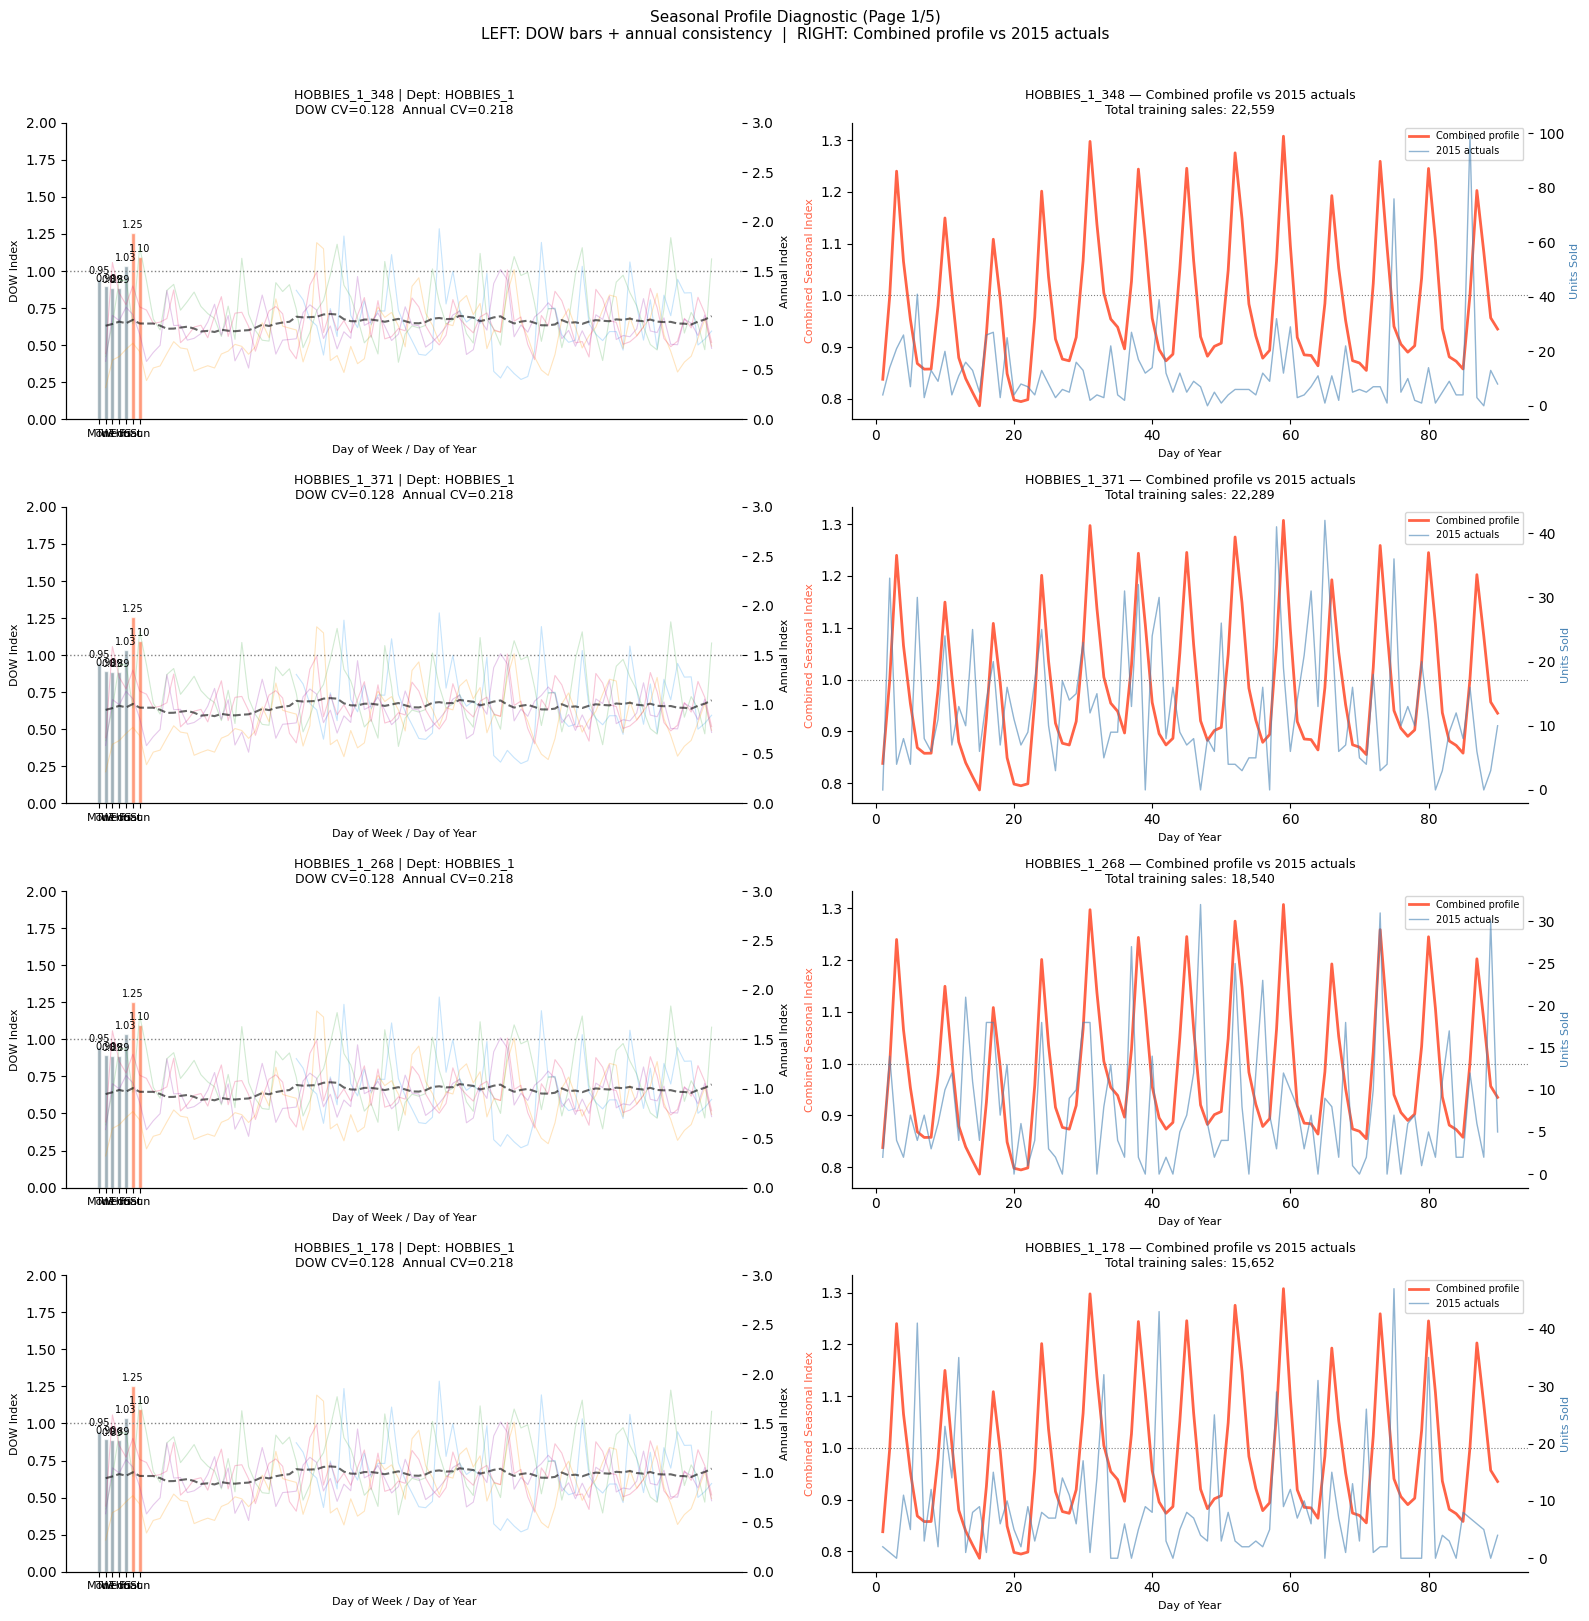

   Page 1/5 rendered


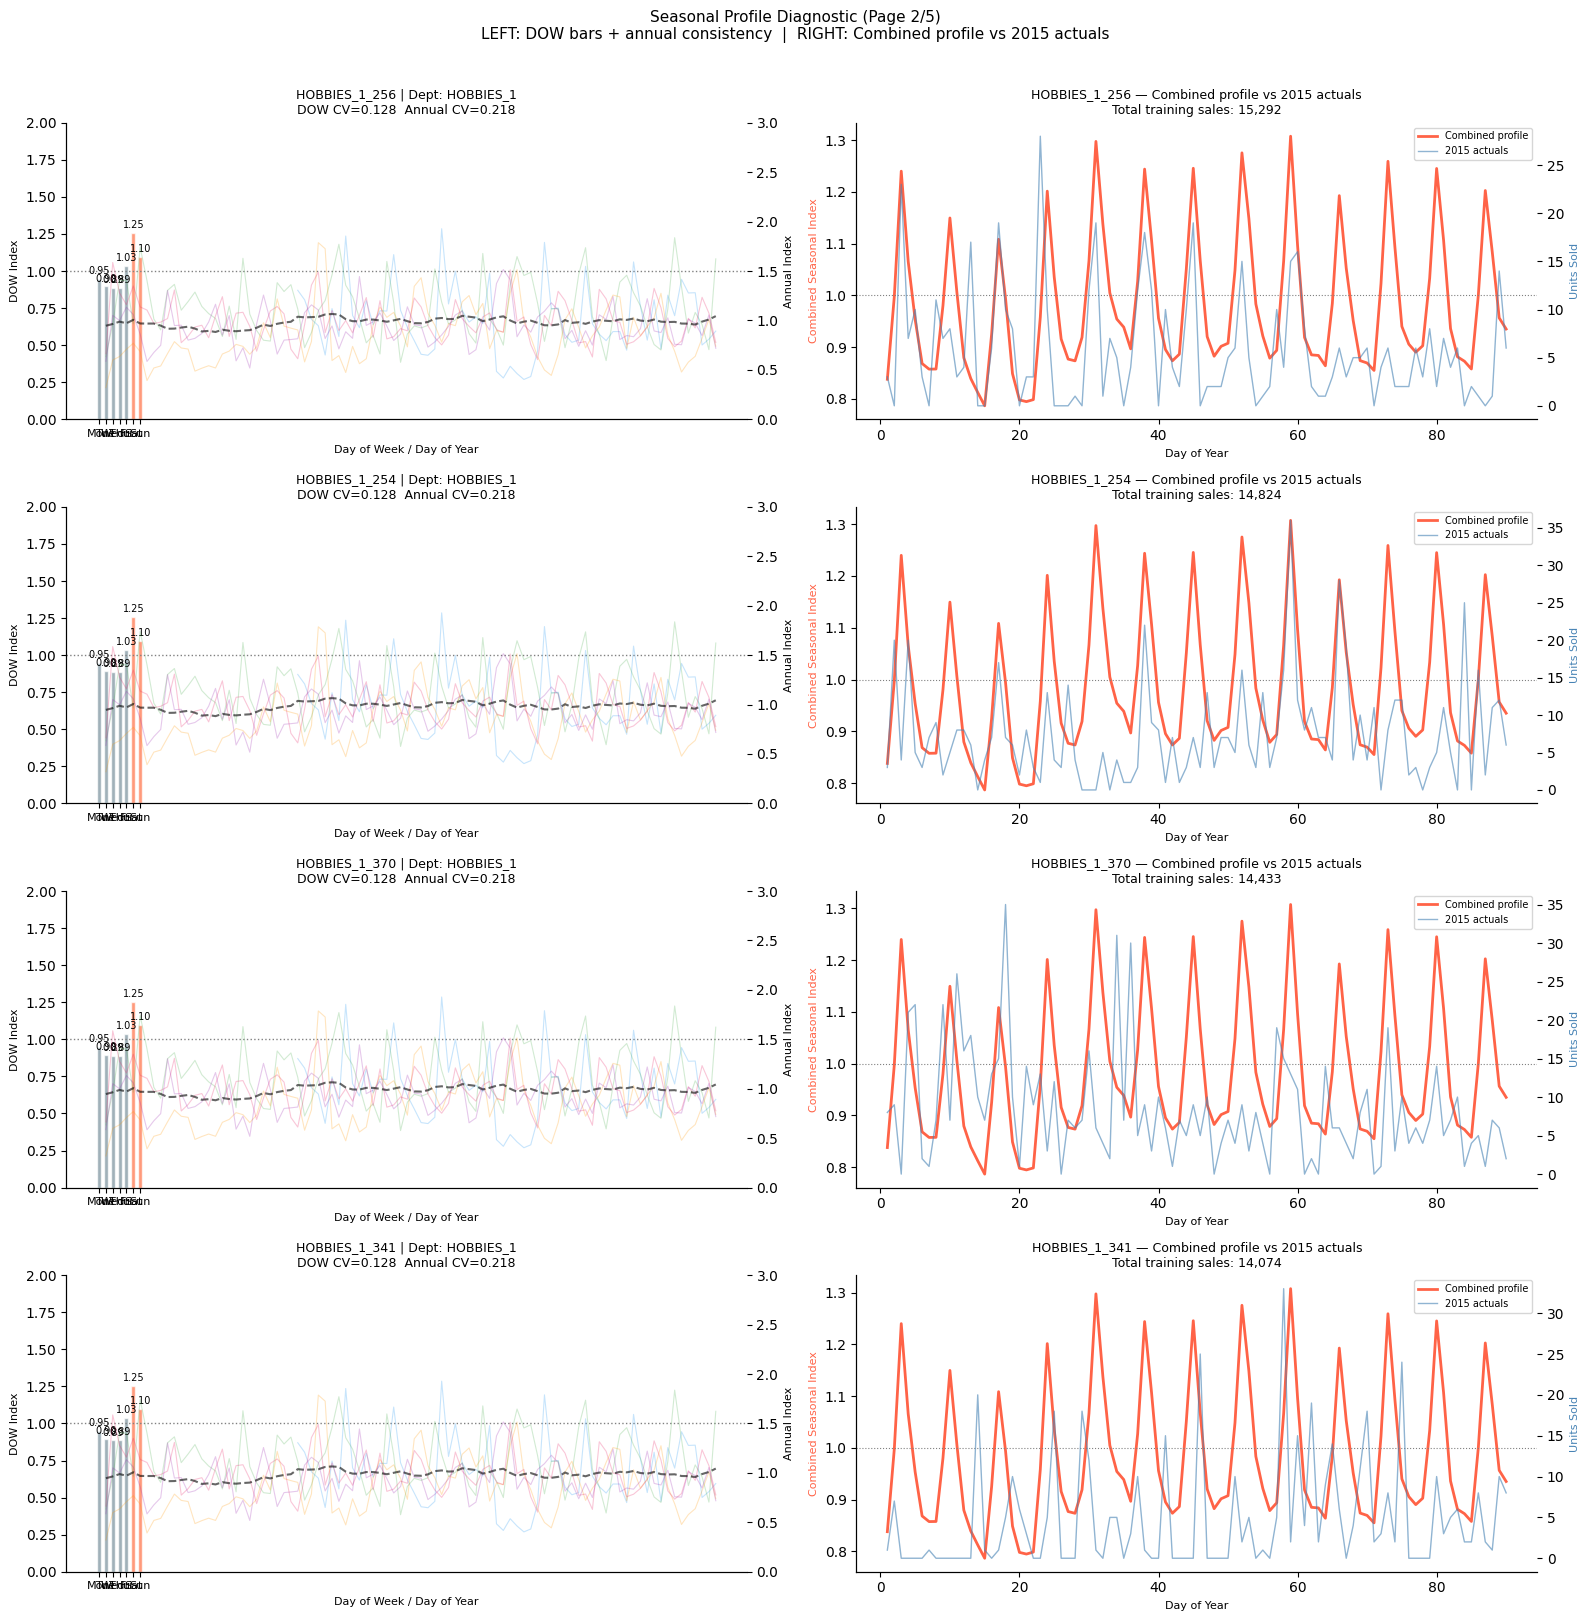

   Page 2/5 rendered


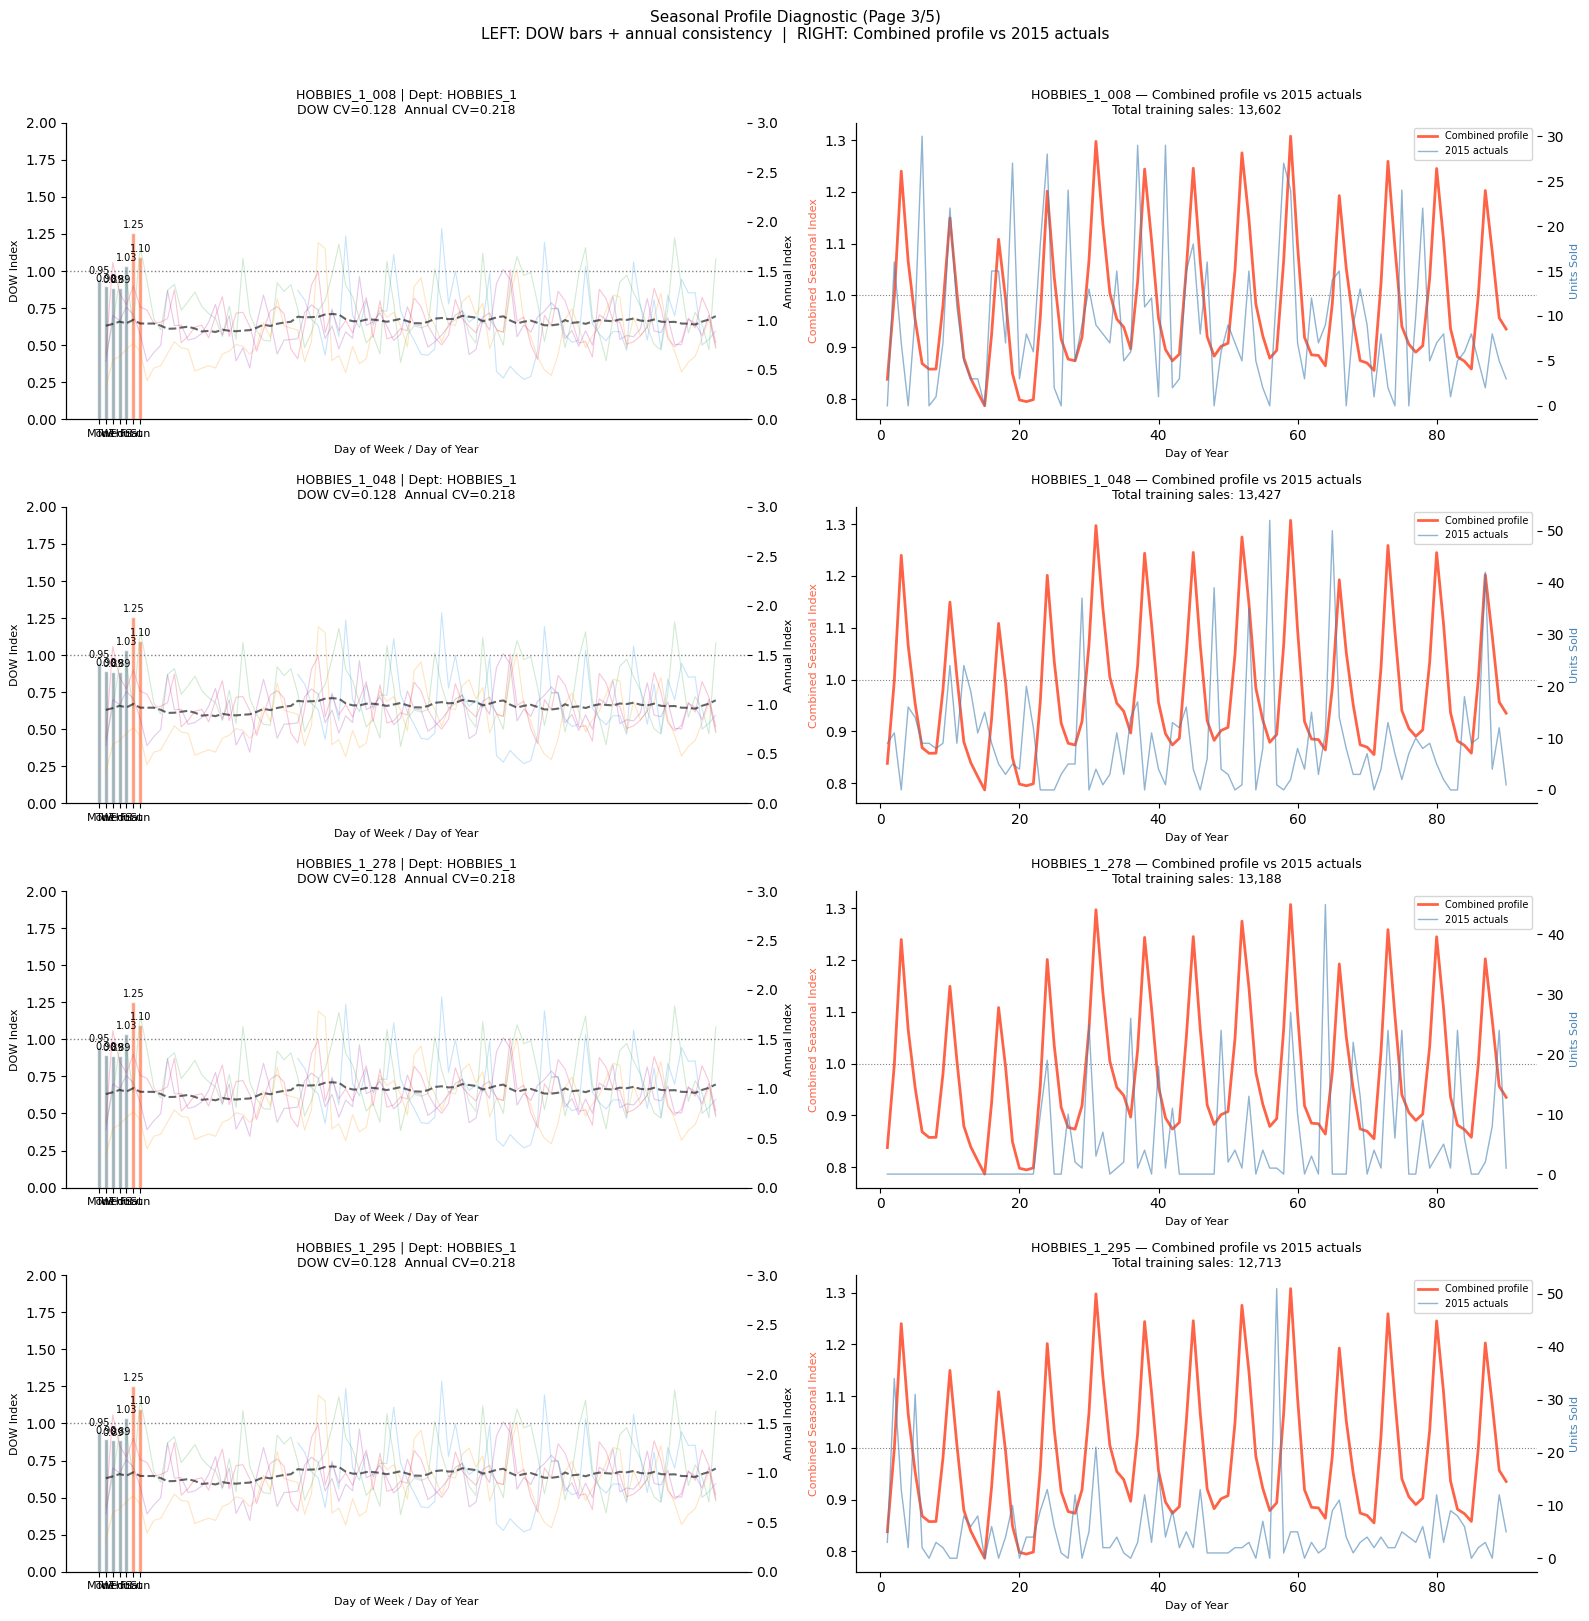

   Page 3/5 rendered


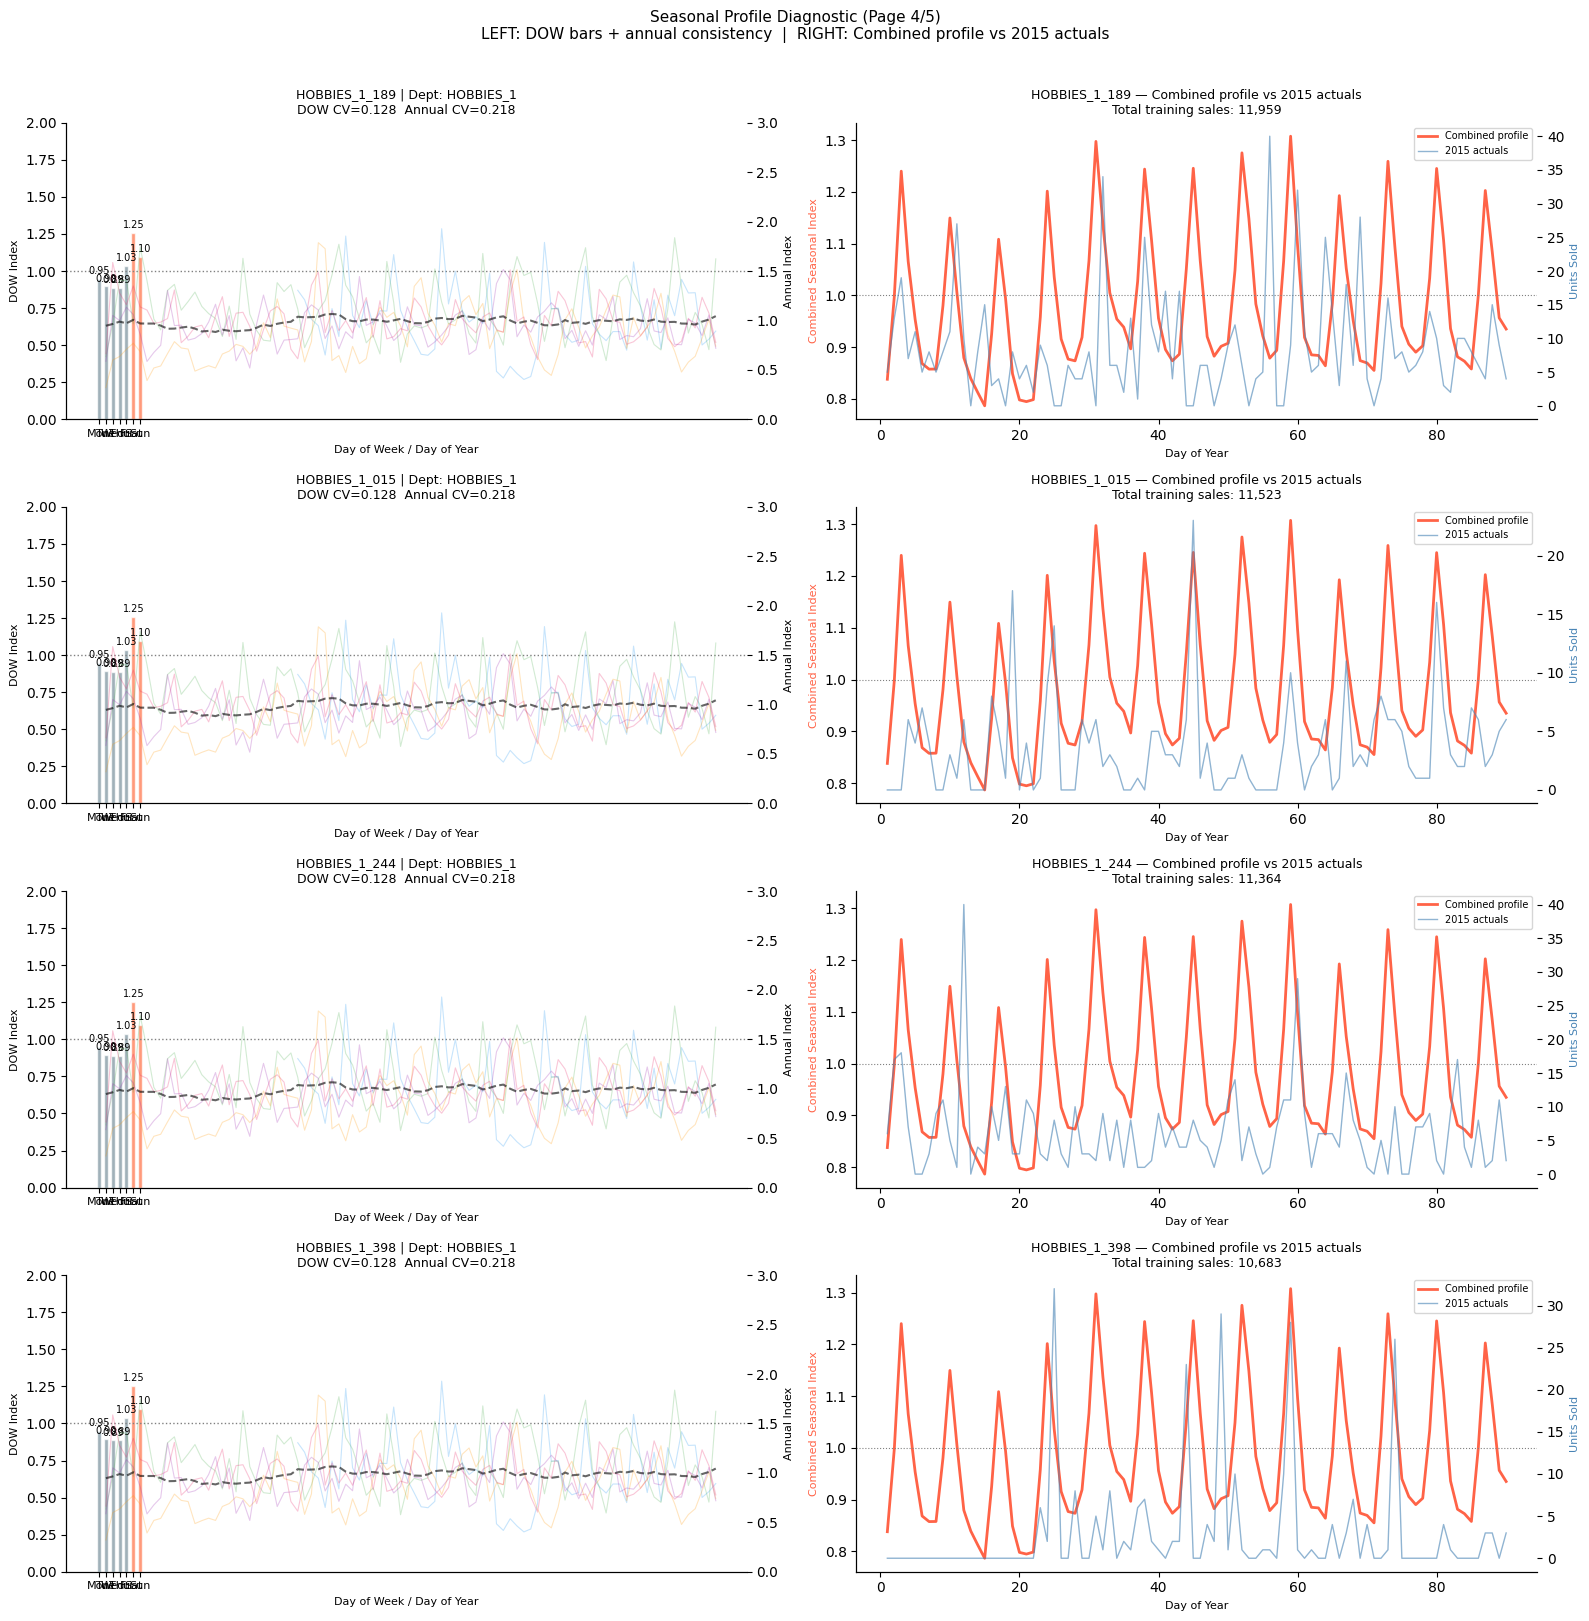

   Page 4/5 rendered


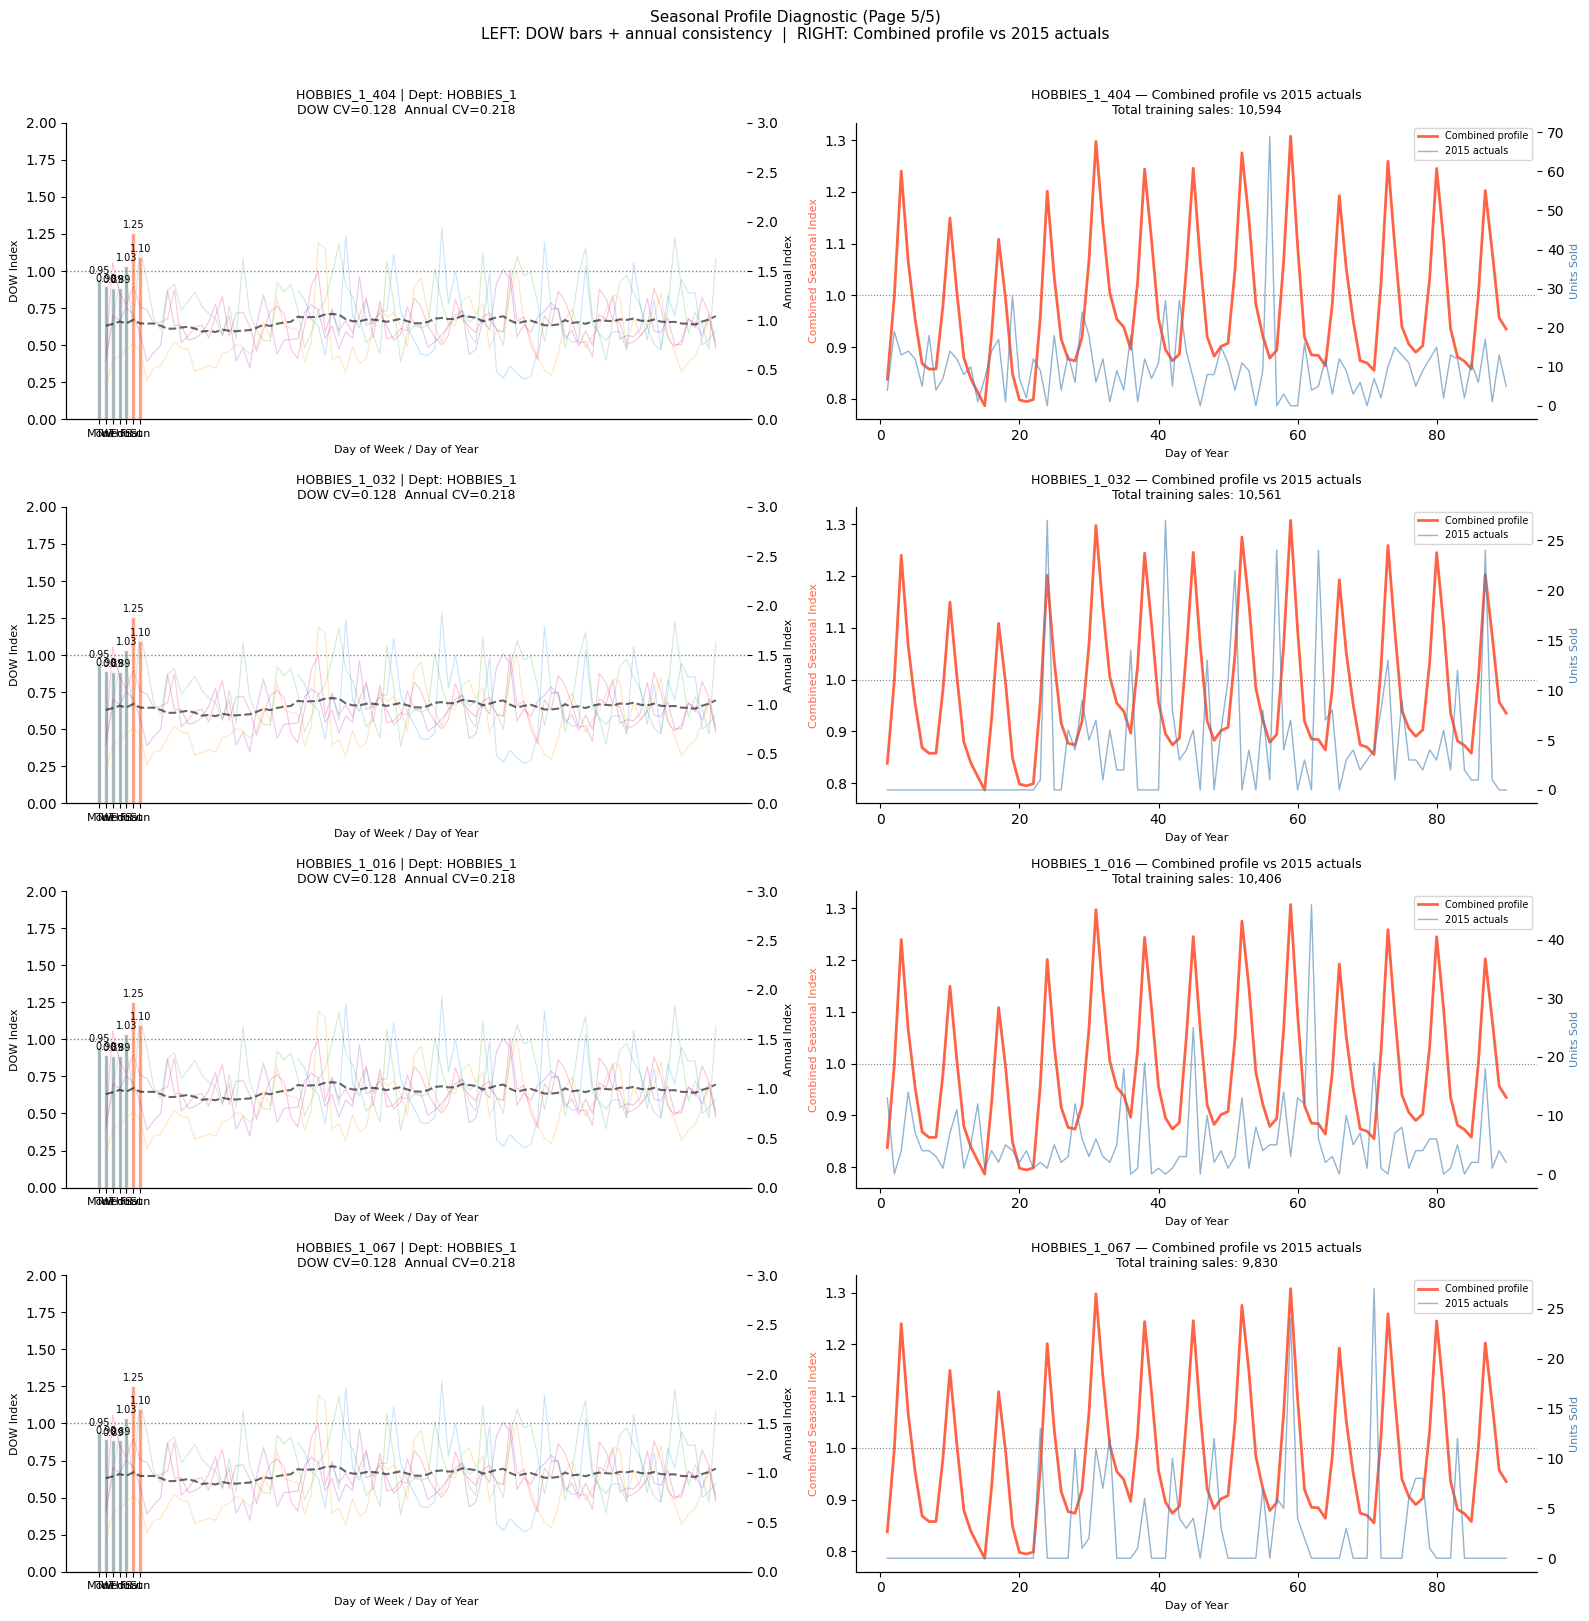

   Page 5/5 rendered

✅ Diagnostic plots complete.


In [ ]:
# Top 20 items by total training sales
# LEFT:  DOW bar chart + annual year-over-year consistency
# RIGHT: Combined profile fit vs 2015 actual sales

item_revenue = (
    train_df.groupby('item_id')['sales']
    .sum().sort_values(ascending=False).head(20)
)
top_items = item_revenue.index.tolist()
print(f'📊 Generating diagnostic plots for top 20 items by volume...')

def get_raw_annual_indices(group_sales, group_dates):
    s = pd.Series(group_sales.values, index=pd.to_datetime(group_dates.values), dtype=np.float64)
    nonzero_dates = s[s > 0].index
    if len(nonzero_dates) == 0:
        return {}
    s = s[:nonzero_dates.max()]
    raw_indices = {}
    for year, year_data in s.groupby(s.index.year):
        if len(year_data) < MIN_YEAR_DAYS:
            continue
        year_mean = year_data.mean()
        if year_mean == 0:
            continue
        raw_indices[year] = year_data / year_mean
    return raw_indices

dept_raw_indices = {}
for dept_id in train_df['dept_id'].unique():
    grp = train_df[train_df['dept_id'] == dept_id].groupby('date')['sales'].sum().reset_index()
    dept_raw_indices[dept_id] = get_raw_annual_indices(grp['sales'], grp['date'])

items_per_page = 4
n_pages        = (len(top_items) + items_per_page - 1) // items_per_page
colors         = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']
dow_names_list = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_colors     = ['#78909C'] * 5 + ['#FF7043', '#FF7043']

for page in range(n_pages):
    page_items = top_items[page * items_per_page:(page + 1) * items_per_page]
    n_rows     = len(page_items)
    fig, axes  = plt.subplots(n_rows, 2, figsize=(16, n_rows * 4))
    if n_rows == 1:
        axes = axes.reshape(1, 2)
    fig.suptitle(
        f'Seasonal Profile Diagnostic (Page {page+1}/{n_pages})\n'
        f'LEFT: DOW bars + annual consistency  |  RIGHT: Combined profile vs 2015 actuals',
        fontsize=11, y=1.01
    )
    for row_idx, item_id in enumerate(page_items):
        dept_id      = sales_raw[sales_raw['item_id'] == item_id]['dept_id'].values[0]
        profile      = item_profiles[item_id]
        dept_cv      = profiles['dept_store'][dept_id]['mean_cv']
        dow_cv       = profiles['dept_store'][dept_id]['dow_cv']
        dow_idx      = profile['dow']
        ax           = axes[row_idx, 0]
        ax2          = ax.twinx()
        dow_vals     = [dow_idx.get(d, 1.0) for d in range(7)]
        bars         = ax.bar(dow_names_list, dow_vals, color=dow_colors, alpha=0.7, edgecolor='white', width=0.6)
        ax.axhline(y=1.0, color='gray', linestyle=':', linewidth=1)
        ax.set_ylabel('DOW Index', fontsize=8)
        ax.set_ylim(0, 2.0)
        ax.set_xticks(range(7))
        ax.set_xticklabels(dow_names_list, fontsize=8)
        plot_days      = range(1, 91)
        raw_by_year    = dept_raw_indices.get(dept_id, {})
        annual_profile = profiles['dept_store'][dept_id]['annual']
        for i, (year, idx_series) in enumerate(raw_by_year.items()):
            doy_vals_yr = {d.timetuple().tm_yday: v for d, v in idx_series.items()}
            y_vals = [doy_vals_yr.get(d, np.nan) for d in plot_days]
            ax2.plot(plot_days, y_vals, color=colors[i % len(colors)], alpha=0.25, linewidth=0.8)
        annual_vals = [annual_profile.get(d, 1.0) for d in plot_days]
        ax2.plot(plot_days, annual_vals, color='black', linewidth=1.5, linestyle='--', alpha=0.6)
        ax2.set_ylabel('Annual Index', fontsize=8)
        ax2.set_ylim(0, 3.0)
        ax.set_title(f'{item_id} | Dept: {dept_id}\nDOW CV={dow_cv:.3f}  Annual CV={dept_cv:.3f}', fontsize=9)
        ax.set_xlabel('Day of Week / Day of Year', fontsize=8)
        for bar, val in zip(bars, dow_vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=7)
        ax  = axes[row_idx, 1]
        ax2 = ax.twinx()
        item_2015 = train_df[(train_df['item_id'] == item_id) & (train_df['date'].dt.year == 2015)].sort_values('date')
        if len(item_2015) > 0:
            doys_2015     = item_2015['date'].dt.dayofyear.values
            sales_2015    = item_2015['sales'].values
            combined_vals = [profile['combined'].get(int(d), 1.0) for d in doys_2015]
            ax.plot(doys_2015[:90], combined_vals[:90], color='tomato', linewidth=2, label='Combined profile')
            ax2.plot(doys_2015[:90], sales_2015[:90], color='steelblue', linewidth=1, alpha=0.6, label='2015 actuals')
            ax.axhline(y=1.0, color='gray', linestyle=':', linewidth=0.8)
        total_sales = item_revenue.get(item_id, 0)
        ax.set_title(f'{item_id} — Combined profile vs 2015 actuals\nTotal training sales: {total_sales:,.0f}', fontsize=9)
        ax.set_xlabel('Day of Year', fontsize=8)
        ax.set_ylabel('Combined Seasonal Index', color='tomato', fontsize=8)
        ax2.set_ylabel('Units Sold', color='steelblue', fontsize=8)
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc='upper right')
    plt.tight_layout()
    plt.show()
    print(f'   Page {page+1}/{n_pages} rendered')

print(f'\n✅ Diagnostic plots complete.')

### Cell 7: De-seasonalize Sales

📉 De-seasonalizing sales...

✅ De-seasonalization complete.
   Raw sales mean:          0.8111
   De-seasonalized mean:    0.8223

📅 Spot check — HOBBIES_1_348, week of Jan 5 2015:
Day     Raw Sales    Index  De-season      Check
------------------------------------------------
Mon           7.0    0.953      7.343      7.343
Tue          41.0    0.868     47.220     47.220
Wed           3.0    0.857      3.499      3.499
Thu          13.0    0.858     15.158     15.158
Fri           9.0    0.980      9.182      9.182
Sat          20.0    1.149     17.399     17.399
Sun           4.0    1.006      3.975      3.975


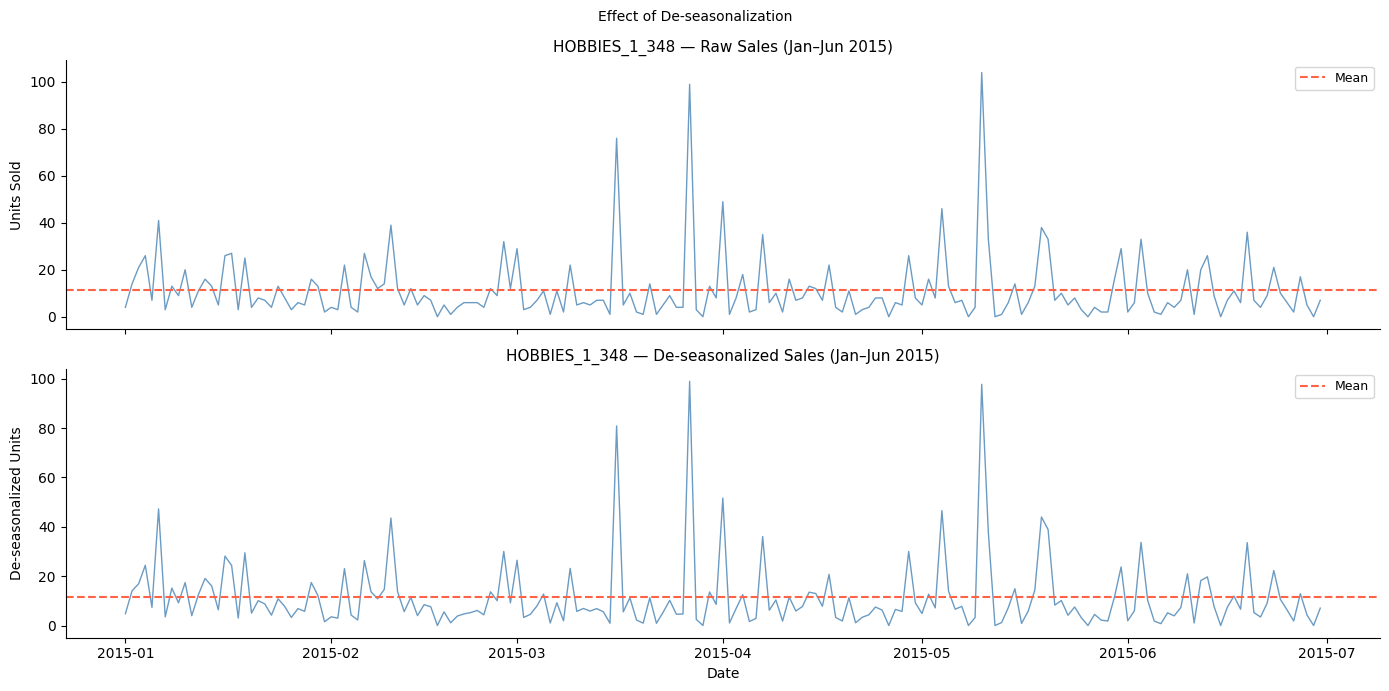

In [ ]:
print('📉 De-seasonalizing sales...\n')

MIN_INDEX = 0.1
df['seasonal_index_safe'] = df['seasonal_index'].clip(lower=MIN_INDEX)
df['sales_deseason']      = (df['sales'] / df['seasonal_index_safe']).astype(np.float32)

print(f'✅ De-seasonalization complete.')
print(f'   Raw sales mean:          {df["sales"].mean():.4f}')
print(f'   De-seasonalized mean:    {df["sales_deseason"].mean():.4f}')

# Spot check using string item ID
sample_item = 'HOBBIES_1_348'
sample_week = df[
    (df['item_id_str'] == sample_item) &
    (df['date'] >= '2015-01-05') &
    (df['date'] <= '2015-01-11')
][['date', 'dow', 'sales', 'seasonal_index', 'sales_deseason']].copy()

dow_names_map = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
sample_week['day'] = sample_week['dow'].map(dow_names_map)

print(f'\n📅 Spot check — {sample_item}, week of Jan 5 2015:')
print(f'{"Day":<6} {"Raw Sales":>10} {"Index":>8} {"De-season":>10} {"Check":>10}')
print('-' * 48)
for _, row in sample_week.iterrows():
    idx_safe = max(float(row['seasonal_index']), MIN_INDEX)
    check    = float(row['sales']) / idx_safe if idx_safe > 0 else 0
    print(f"{row['day']:<6} {float(row['sales']):>10.1f} {float(row['seasonal_index']):>8.3f} {float(row['sales_deseason']):>10.3f} {check:>10.3f}")

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
item_data = df[(df['item_id_str'] == sample_item) & (df['date'] >= '2015-01-01') & (df['date'] <= '2015-06-30')].sort_values('date')
axes[0].plot(item_data['date'], item_data['sales'], color='steelblue', linewidth=1, alpha=0.8)
axes[0].set_title(f'{sample_item} — Raw Sales (Jan–Jun 2015)', fontsize=11)
axes[0].set_ylabel('Units Sold')
axes[0].axhline(y=item_data['sales'].mean(), color='tomato', linestyle='--', linewidth=1.5, label='Mean')
axes[0].legend(fontsize=9)
axes[1].plot(item_data['date'], item_data['sales_deseason'], color='steelblue', linewidth=1, alpha=0.8)
axes[1].set_title(f'{sample_item} — De-seasonalized Sales (Jan–Jun 2015)', fontsize=11)
axes[1].set_ylabel('De-seasonalized Units')
axes[1].axhline(y=item_data['sales_deseason'].mean(), color='tomato', linestyle='--', linewidth=1.5, label='Mean')
axes[1].legend(fontsize=9)
axes[1].set_xlabel('Date')
plt.suptitle('Effect of De-seasonalization', fontsize=10)
plt.tight_layout()
plt.show()

### Cell 8: Test MA Windows and Select Best Per Item

🔍 Testing MA windows on holdout period...

   Holdout period: 2016-01-31 → 2016-03-27 (56 days)
   Windows tested: ['13 weeks (91 days)', '26 weeks (182 days)']

   Pre-holdout rows: 1,033,385
   Holdout rows:     31,640

📊 Window selection results:
Window           Items      Pct   Median wMAPE
---------------------------------------------
13 weeks (91d)     264    46.7%        133.3%
26 weeks (182d)     272    48.1%        126.1%

   Items defaulted (no holdout sales): 29
   Overall median holdout wMAPE: 129.5%


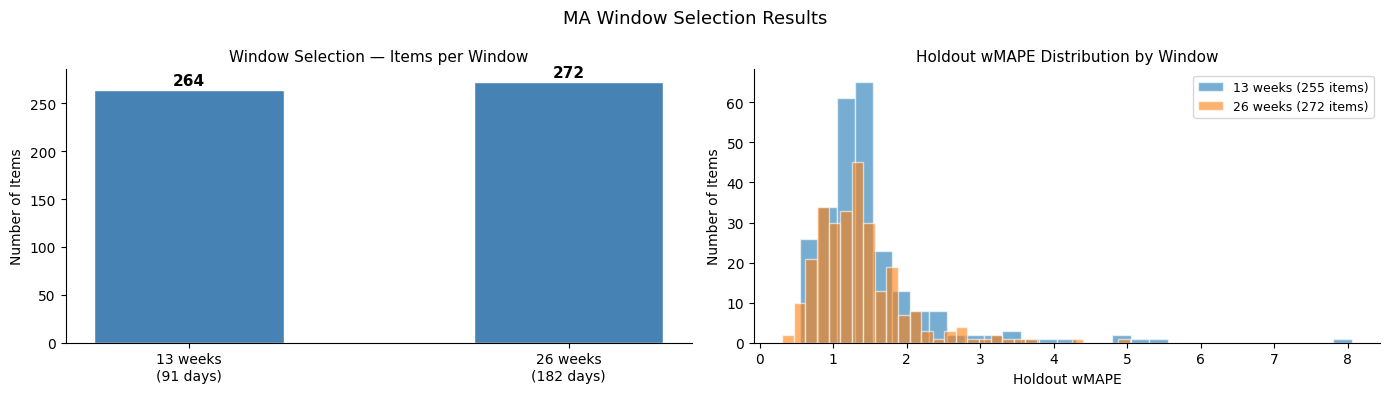

In [ ]:
print('🔍 Testing MA windows on holdout period...\n')
print(f'   Holdout period: {holdout_cutoff.date()} → {val_cutoff.date()} ({HOLDOUT_DAYS} days)')
print(f'   Windows tested: {[f"{w//7} weeks ({w} days)" for w in WINDOWS]}\n')

pre_holdout = df[df['date'] <= holdout_cutoff].copy()
holdout     = df[(df['date'] > holdout_cutoff) & (df['date'] <= val_cutoff)].copy()

print(f'   Pre-holdout rows: {len(pre_holdout):,}')
print(f'   Holdout rows:     {len(holdout):,}\n')

item_window_selection = {}
all_results           = []

# Iterate using string item IDs
for item_id in sales_raw['item_id'].unique():
    item_pre  = pre_holdout[pre_holdout['item_id_str'] == item_id].sort_values('date')
    item_hold = holdout[holdout['item_id_str'] == item_id].sort_values('date')

    if len(item_hold) == 0 or item_hold['sales'].sum() == 0:
        item_window_selection[item_id] = {'window': WINDOWS[0], 'wmape': np.nan}
        continue

    best_window = WINDOWS[0]
    best_wmape  = np.inf

    for window in WINDOWS:
        window_data = item_pre.tail(window)
        if len(window_data) == 0 or window_data['sales_deseason'].sum() == 0:
            continue
        baseline          = window_data['sales_deseason'].mean()
        item_hold_copy    = item_hold.copy()
        item_hold_copy['pred'] = (baseline * item_hold_copy['seasonal_index']).clip(lower=0)
        abs_errors = np.abs(item_hold_copy['sales'] - item_hold_copy['pred'])
        actual_sum = item_hold_copy['sales'].sum()
        wmape      = abs_errors.sum() / actual_sum if actual_sum > 0 else np.inf
        if wmape < best_wmape:
            best_wmape  = wmape
            best_window = window

    item_window_selection[item_id] = {'window': best_window, 'wmape': best_wmape}
    all_results.append({'item_id': item_id, 'window': best_window, 'wmape': best_wmape})

results_df = pd.DataFrame(all_results)

print('📊 Window selection results:')
print(f'{"Window":<15} {"Items":>6} {"Pct":>8} {"Median wMAPE":>14}')
print('-' * 45)
for window in WINDOWS:
    subset = results_df[results_df['window'] == window]
    count  = len(subset)
    pct    = count / N_ITEMS * 100
    med    = subset['wmape'].median() if len(subset) > 0 else np.nan
    print(f'{window//7} weeks ({window}d)  {count:>6} {pct:>7.1f}% {med:>13.1%}')
print(f'\n   Items defaulted (no holdout sales): {N_ITEMS - len(all_results)}')
print(f'   Overall median holdout wMAPE: {results_df["wmape"].median():.1%}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
window_counts = results_df['window'].value_counts().sort_index()
labels = [f'{w//7} weeks\n({w} days)' for w in window_counts.index]
axes[0].bar(labels, window_counts.values, color='steelblue', edgecolor='white', width=0.5)
axes[0].set_title('Window Selection — Items per Window', fontsize=11)
axes[0].set_ylabel('Number of Items')
for i, (label, val) in enumerate(zip(labels, window_counts.values)):
    axes[0].text(i, val + 2, str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
for window in WINDOWS:
    subset = results_df[(results_df['window'] == window) & (results_df['wmape'] < 10)]
    axes[1].hist(subset['wmape'], bins=30, alpha=0.6, label=f'{window//7} weeks ({len(subset)} items)', edgecolor='white')
axes[1].set_title('Holdout wMAPE Distribution by Window', fontsize=11)
axes[1].set_xlabel('Holdout wMAPE')
axes[1].set_ylabel('Number of Items')
axes[1].legend(fontsize=9)
plt.suptitle('MA Window Selection Results', fontsize=13)
plt.tight_layout()
plt.show()

### Cell 8.5: Compute Promotional Lift Factors (Seasonal MA)

In [ ]:
print('Computing promotional lift factors...\n')

PROMO_THRESHOLD = 0.95   # >5% below reference price = on promotion
MIN_PROMO_DAYS  = 14     # min promo days for item-level estimate
DEFAULT_LIFT    = 1.3    # fallback if no dept-level data available

# Define training window — same split used by Cell 9
# Defined here so Cell 8.5 can run independently
train_data = df[df['date'] <= val_cutoff].copy()

# Merge sell prices onto training data using wm_yr_wk join
calendar_wk = calendar[['date','wm_yr_wk']].copy()
calendar_wk['date'] = pd.to_datetime(calendar_wk['date'])

train_priced = train_data.merge(calendar_wk, on='date', how='left')
train_priced = train_priced.merge(
    prices[['item_id','store_id','wm_yr_wk','sell_price']],
    left_on=['item_id_str','store_id','wm_yr_wk'],
    right_on=['item_id','store_id','wm_yr_wk'],
    how='left',
    suffixes=('','_p')
)
if 'item_id_p' in train_priced.columns:
    train_priced.drop(columns=['item_id_p'], inplace=True)

print(f'   Training rows with price data: '
      f'{train_priced["sell_price"].notna().sum():,} / {len(train_priced):,}')

# Department-level lift as fallback for sparse items
print('\n   Computing department-level lift factors...')
dept_promo_lifts = {}

for dept_id in train_priced['dept_id'].unique():
    dept_data = train_priced[train_priced['dept_id']==dept_id].copy()
    item_refs = dept_data.groupby('item_id_str')['sell_price'].median()
    dept_data = dept_data.merge(
        item_refs.rename('ref_price'),
        left_on='item_id_str', right_index=True, how='left'
    )
    dept_data['on_promo'] = (
        dept_data['sell_price'] < dept_data['ref_price'] * PROMO_THRESHOLD
    )
    reg_sales   = dept_data[(~dept_data['on_promo']) & (dept_data['sales']>0)]['sales_deseason'].mean()
    promo_sales = dept_data[(dept_data['on_promo'])  & (dept_data['sales']>0)]['sales_deseason'].mean()

    if (dept_data['on_promo'].sum() >= MIN_PROMO_DAYS
            and reg_sales > 0
            and not np.isnan(promo_sales)):
        lift = np.clip(promo_sales / reg_sales, 1.0, 5.0)
    else:
        lift = DEFAULT_LIFT

    dept_promo_lifts[dept_id] = lift
    print(f'   Dept {dept_id}: lift={lift:.3f}  '
          f'({dept_data["on_promo"].sum()} promo days)')

# Item-level lift factors
print('\n   Computing item-level lift factors...')
item_price_stats = {}
n_item_level, n_dept_fallback, n_no_price = 0, 0, 0

for item_id in sales_raw['item_id'].unique():
    dept_id   = sales_raw[sales_raw['item_id']==item_id]['dept_id'].values[0]
    item_data = train_priced[train_priced['item_id_str']==item_id].copy()

    if item_data['sell_price'].isna().all():
        item_price_stats[item_id] = {
            'ref_price': None,
            'promo_lift': dept_promo_lifts.get(dept_id, DEFAULT_LIFT),
            'n_promo_days': 0
        }
        n_no_price += 1
        continue

    ref_price = item_data['sell_price'].median()
    item_data['on_promo'] = item_data['sell_price'] < ref_price * PROMO_THRESHOLD

    reg_sales   = item_data[(~item_data['on_promo']) & (item_data['sales']>0)]['sales_deseason'].mean()
    promo_sales = item_data[(item_data['on_promo'])  & (item_data['sales']>0)]['sales_deseason'].mean()
    n_promo_days = int(item_data['on_promo'].sum())

    if (n_promo_days >= MIN_PROMO_DAYS
            and reg_sales > 0
            and not np.isnan(promo_sales)):
        promo_lift = np.clip(promo_sales / reg_sales, 1.0, 5.0)
        n_item_level += 1
    else:
        promo_lift = dept_promo_lifts.get(dept_id, DEFAULT_LIFT)
        n_dept_fallback += 1

    item_price_stats[item_id] = {
        'ref_price':    ref_price,
        'promo_lift':   promo_lift,
        'n_promo_days': n_promo_days
    }

print(f'\nLift factors computed for {len(item_price_stats):,} items')
print(f'   Item-level estimate:  {n_item_level:,} ({n_item_level/N_ITEMS*100:.1f}%)')
print(f'   Dept-level fallback:  {n_dept_fallback:,} ({n_dept_fallback/N_ITEMS*100:.1f}%)')
print(f'   No price data:        {n_no_price:,}')

lift_vals = [v['promo_lift'] for v in item_price_stats.values()]
print(f'\nLift factor distribution:')
print(f'   Mean:    {np.mean(lift_vals):.3f}')
print(f'   Median:  {np.median(lift_vals):.3f}')
print(f'   Min:     {np.min(lift_vals):.3f}')
print(f'   Max:     {np.max(lift_vals):.3f}')
print(f'   Items with lift > 1.5 (strong promo response): '
      f'{sum(v > 1.5 for v in lift_vals)}')

print(f'\nSample items:')
print(f'{"Item":<20} {"Ref Price":>10} {"Lift":>8} {"Promo Days":>12} {"Source":>15}')
print('-' * 68)
for item_id in list(item_price_stats.keys())[:8]:
    stats    = item_price_stats[item_id]
    dept_id  = sales_raw[sales_raw['item_id']==item_id]['dept_id'].values[0]
    dept_lft = dept_promo_lifts.get(dept_id, DEFAULT_LIFT)
    source   = 'item-level' if abs(stats['promo_lift']-dept_lft)>0.001 else 'dept fallback'
    ref_str  = f'${stats["ref_price"]:.2f}' if stats['ref_price'] is not None else 'N/A'
    print(f'{item_id:<20} {ref_str:>10} {stats["promo_lift"]:>8.3f} '
          f'{stats["n_promo_days"]:>12} {source:>15}')

Computing promotional lift factors...

   Training rows with price data: 857,118 / 1,065,025

   Computing department-level lift factors...
   Dept HOBBIES_1: lift=1.128  (51286 promo days)
   Dept HOBBIES_2: lift=1.083  (27551 promo days)

   Computing item-level lift factors...

Lift factors computed for 565 items
   Item-level estimate:  219 (38.8%)
   Dept-level fallback:  346 (61.2%)
   No price data:        0

Lift factor distribution:
   Mean:    1.143
   Median:  1.128
   Min:     1.000
   Max:     3.621
   Items with lift > 1.5 (strong promo response): 14

Sample items:
Item                  Ref Price     Lift   Promo Days          Source
--------------------------------------------------------------------
HOBBIES_1_001             $8.26    1.128            0   dept fallback
HOBBIES_1_002             $3.97    1.128            0   dept fallback
HOBBIES_1_003             $2.97    1.128            0   dept fallback
HOBBIES_1_004             $4.64    1.000          721      item-l

### Cell 9: Generate 28-Day Seasonal MA Forecast

In [ ]:
print('Generating 28-day Seasonal MA forecast...\n')

future_dates = pd.date_range(
    start=max_date + pd.Timedelta(days=1),
    periods=PRED_HORIZON, freq='D'
)

train_data = df[df['date'] <= val_cutoff].copy()
valid_data = df[(df['date'] > val_cutoff) & (df['date'] <= max_date)].copy()

# Merge sell prices onto validation data
# Needed to determine if items are on promotion during validation
calendar_wk = calendar[['date','wm_yr_wk']].copy()
calendar_wk['date'] = pd.to_datetime(calendar_wk['date'])

valid_data = valid_data.merge(calendar_wk, on='date', how='left')
valid_data = valid_data.merge(
    prices[['item_id','store_id','wm_yr_wk','sell_price']],
    left_on=['item_id_str','store_id','wm_yr_wk'],
    right_on=['item_id','store_id','wm_yr_wk'],
    how='left', suffixes=('','_p')
)
if 'item_id_p' in valid_data.columns:
    valid_data.drop(columns=['item_id_p'], inplace=True)

# Per-item median validation price
item_val_prices = valid_data.groupby('item_id_str')['sell_price'].median()

print(f'Training window:   {train_data["date"].min().date()} to {train_data["date"].max().date()}')
print(f'Validation window: {valid_data["date"].min().date()} to {valid_data["date"].max().date()}')
print(f'Forecast window:   {future_dates[0].date()} to {future_dates[-1].date()}')
print(f'Items to forecast: {N_ITEMS}\n')

sma_val_preds    = []
sma_future_preds = []
n_promo_items    = 0

for item_id in sales_raw['item_id'].unique():
    window  = item_window_selection[item_id]['window']
    profile = item_profiles[item_id]

    # Baseline from last N days of training
    item_train   = train_data[train_data['item_id_str']==item_id].sort_values('date')
    window_data  = item_train.tail(window)
    val_baseline = window_data['sales_deseason'].mean()
    if np.isnan(val_baseline) or val_baseline < 0:
        val_baseline = 0.0

    # Price multiplier: is item on promotion during validation?
    # forecast = baseline x seasonal_index x price_multiplier
    stats         = item_price_stats.get(item_id, {})
    ref_price     = stats.get('ref_price', None)
    promo_lift    = stats.get('promo_lift', 1.0)
    val_price     = item_val_prices.get(item_id, None)

    if (ref_price is not None
            and val_price is not None
            and not np.isnan(val_price)
            and val_price < ref_price * PROMO_THRESHOLD):
        price_multiplier = promo_lift
        n_promo_items   += 1
    else:
        price_multiplier = 1.0

    # Validation predictions
    item_val = valid_data[valid_data['item_id_str']==item_id].sort_values('date')
    for _, row in item_val.iterrows():
        pred = max(0, val_baseline * float(row['seasonal_index']) * price_multiplier)
        sma_val_preds.append({
            'item_id':          item_id,
            'date':             row['date'],
            'actual':           float(row['sales']),
            'pred_sma':         pred,
            'seasonal_index':   float(row['seasonal_index']),
            'price_multiplier': price_multiplier,
            'dept_id':          row['dept_id'],
            'cat_id':           row['cat_id'],
        })

    # Future predictions
    full_train   = df[df['item_id_str']==item_id].sort_values('date')
    full_window  = full_train.tail(window)
    fut_baseline = full_window['sales_deseason'].mean()
    if np.isnan(fut_baseline) or fut_baseline < 0:
        fut_baseline = 0.0

    for fdate in future_dates:
        doy  = fdate.timetuple().tm_yday
        sidx = profile['combined'].get(doy, 1.0)
        pred = max(0, fut_baseline * sidx * price_multiplier)
        sma_future_preds.append({'item_id': item_id, 'date': fdate, 'pred_sma': pred})

sma_val_df    = pd.DataFrame(sma_val_preds)
sma_future_df = pd.DataFrame(sma_future_preds)

abs_errors  = np.abs(sma_val_df['actual'] - sma_val_df['pred_sma'])
actual_sum  = sma_val_df['actual'].sum()
wmape_quick = abs_errors.sum() / actual_sum * 100

print(f'Forecasts generated.')
print(f'   Validation predictions: {len(sma_val_df):,} rows')
print(f'   Future predictions:     {len(sma_future_df):,} rows')
print(f'   Items on promotion:     {n_promo_items} / {N_ITEMS}')
print(f'\nValidation: {sma_val_df["date"].min().date()} to {sma_val_df["date"].max().date()}')
print(f'Total actual:    {actual_sum:,.0f} units')
print(f'Total predicted: {sma_val_df["pred_sma"].sum():,.1f} units')
print(f'Portfolio wMAPE: {wmape_quick:.1f}%')

if n_promo_items > 0:
    promo_df = sma_val_df[sma_val_df['price_multiplier']>1.0][
        ['item_id','price_multiplier']].drop_duplicates()
    print(f'\nItems on promotion during validation:')
    print(promo_df.to_string(index=False))
else:
    print(f'\nNo items on promotion during validation window.')
    print(f'Price multiplier = 1.0 for all items.')
    print(f'(Expected -- impact visible at full scale with frequent promotions)')

# Plot 3 sample items
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=False)
item_rev  = train_data.groupby('item_id_str')['sales'].sum().sort_values(ascending=False)
high_item = item_rev.index[0]
mid_item  = item_rev.index[len(item_rev)//2]
low_item  = item_rev.index[-1]

for ax, item_id, label in zip(axes,
    [high_item, mid_item, low_item],
    ['High volume', 'Mid volume', 'Low volume']):
    ih  = train_data[train_data['item_id_str']==item_id].sort_values('date').tail(90)
    ivp = sma_val_df[sma_val_df['item_id']==item_id].sort_values('date')
    ifp = sma_future_df[sma_future_df['item_id']==item_id].sort_values('date')
    pm  = ivp['price_multiplier'].iloc[0] if len(ivp)>0 else 1.0
    tag = f' [PROMO x{pm:.2f}]' if pm > 1.0 else ''
    ax.plot(ih['date'], ih['sales'], color='steelblue', linewidth=1.5, alpha=0.8, label='Historical')
    ax.plot(ivp['date'], ivp['actual'], color='steelblue', linewidth=1.5, linestyle='--', alpha=0.8, label='Actual (validation)')
    ax.plot(ivp['date'], ivp['pred_sma'], color='tomato', linewidth=2, label=f'SMA forecast{tag}')
    ax.plot(ifp['date'], ifp['pred_sma'], color='tomato', linewidth=2, linestyle='--', label='SMA (future)', alpha=0.7)
    ax.axvline(x=val_cutoff, color='gray', linestyle=':', linewidth=1.5)
    ax.axvline(x=max_date,   color='gray', linestyle=':', linewidth=1.5)
    avg_s = item_rev[item_id] / len(ih)
    ax.set_title(f'{label} -- {item_id}  (avg {avg_s:.2f} units/day){tag}', fontsize=10)
    ax.set_ylabel('Units Sold')
    ax.legend(fontsize=8, ncol=3)
axes[-1].set_xlabel('Date')
plt.suptitle('Seasonal MA -- Validation + 28-Day Forward (with price adjustment)', fontsize=11)
plt.tight_layout()
plt.show()

### Cell 10: Evaluate Seasonal MA — wMAPE + WRMSSE

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

print('📐 Computing Seasonal MA evaluation metrics...\n')

actuals_sma  = sma_val_df['actual'].values
preds_sma    = sma_val_df['pred_sma'].values
abs_err_sma  = np.abs(actuals_sma - preds_sma)
nonzero_sma  = actuals_sma > 0

wmape_sma = abs_err_sma.sum() / actuals_sma.sum() * 100
mape_sma  = (abs_err_sma[nonzero_sma] / actuals_sma[nonzero_sma]).mean() * 100
rmse_sma  = np.sqrt(mean_squared_error(actuals_sma, preds_sma))
mae_sma   = mean_absolute_error(actuals_sma, preds_sma)
bias_sma  = np.mean(preds_sma - actuals_sma)


def compute_wrmsse_sma(val_df, train_df_ref):
    """Compute WRMSSE for Seasonal MA predictions."""
    items        = val_df['item_id'].unique()
    total_wrmsse = 0.0
    total_weight = 0.0
    item_scores  = []
    for item in items:
        item_val   = val_df[val_df['item_id'] == item]
        item_tr    = train_df_ref[train_df_ref['item_id_str'] == item].sort_values('date')
        if len(item_val) == 0:
            continue
        ip = item_val['pred_sma'].values
        ia = item_val['actual'].values
        is_ = item_tr['sales'].values.astype(np.float32)
        scale = np.mean(np.diff(is_) ** 2) if len(is_) > 1 else 1.0
        if scale == 0:
            scale = 1.0
        rmsse  = np.sqrt(np.mean((ip - ia) ** 2) / scale)
        last28 = item_tr.tail(28)
        weight = float((last28['sales'] * last28['seasonal_index_safe']).sum()) if 'seasonal_index_safe' in last28.columns else float(last28['sales'].sum())
        weight = max(weight, 0.0)
        total_wrmsse += rmsse * weight
        total_weight += weight
        item_scores.append({
            'item_id': item, 'rmsse': rmsse, 'weight': weight,
            'wrmsse_contribution': rmsse * weight,
            'item_wmape': (np.abs(ip - ia).sum() / ia.sum() * 100 if ia.sum() > 0 else np.nan)
        })
    wrmsse    = total_wrmsse / total_weight if total_weight > 0 else np.nan
    scores_df = pd.DataFrame(item_scores).sort_values('wrmsse_contribution', ascending=False)
    return wrmsse, scores_df


wrmsse_sma, scores_sma = compute_wrmsse_sma(sma_val_df, train_data)

print('=' * 55)
print('  SEASONAL MA — VALIDATION METRICS')
print('=' * 55)
print(f"""
  wMAPE (CPG metric):           {wmape_sma:.1f}%
  MAPE  (non-zero days only):   {mape_sma:.1f}%
  WRMSSE (competition metric):  {wrmsse_sma:.4f}
  RMSE:                         {rmse_sma:.4f}
  MAE:                          {mae_sma:.4f}
  Bias:                         {bias_sma:+.4f} ({'over-predicting' if bias_sma > 0 else 'under-predicting'})

  Validation window:            {sma_val_df['date'].min().date()} → {sma_val_df['date'].max().date()}
  Total actual sales:           {actuals_sma.sum():,.0f} units
  Total predicted sales:        {preds_sma.sum():,.1f} units
  Non-zero actual days:         {nonzero_sma.sum():,} / {len(actuals_sma):,} ({nonzero_sma.mean()*100:.1f}%)
""")

print('📊 Performance by volume tier:')
print(f'{"Tier":<12} {"Items":>6} {"wMAPE":>8} {"MAE":>8} {"Bias":>8}')
print('-' * 45)
item_rev_sma = train_data.groupby('item_id_str')['sales'].sum().sort_values()
n            = len(item_rev_sma)
tiers_sma    = {
    'Low':  item_rev_sma.index[:n//3],
    'Mid':  item_rev_sma.index[n//3:2*n//3],
    'High': item_rev_sma.index[2*n//3:]
}
for tier_name, tier_items in tiers_sma.items():
    tv   = sma_val_df[sma_val_df['item_id'].isin(tier_items)]
    ta   = tv['actual'].values
    tp   = tv['pred_sma'].values
    tw   = np.abs(ta - tp).sum() / ta.sum() * 100 if ta.sum() > 0 else np.nan
    print(f'{tier_name:<12} {len(tier_items):>6} {tw:>7.1f}% {mean_absolute_error(ta, tp):>8.3f} {np.mean(tp-ta):>+8.3f}')

print(f'\n📋 Top 10 hardest items (highest WRMSSE contribution):')
print(scores_sma.head(10)[['item_id', 'rmsse', 'weight', 'wrmsse_contribution', 'item_wmape']].to_string(index=False))

# Multi-level WRMSSE for Seasonal MA
# Mirrors compute_wrmsse_multilevel in Cell 16 but uses SMA column names

def compute_wrmsse_sma_multilevel(val_df, train_df_ref, group_col=None):
    total_wrmsse = 0.0
    total_weight = 0.0
    results      = []

    if group_col == 'portfolio':
        agg_val   = val_df.groupby('date').agg(actual=('actual','sum'),pred=('pred_sma','sum')).reset_index()
        agg_train = train_df_ref.groupby('date')['sales'].sum().reset_index()
        ts    = agg_train['sales'].values
        scale = np.mean(np.diff(ts)**2) if len(ts)>1 else 1.0
        if scale==0: scale=1.0
        rmsse = np.sqrt(np.mean((agg_val['pred'].values-agg_val['actual'].values)**2)/scale)
        return rmsse, rmsse

    if group_col is None:
        grp_ids = val_df['item_id'].unique()
        for grp_id in grp_ids:
            gv = val_df[val_df['item_id']==grp_id]
            gt = train_df_ref[train_df_ref['item_id_str']==grp_id].sort_values('date')
            ts = gt['sales'].values
            ip = gv['pred_sma'].values
            ia = gv['actual'].values
            if len(ts)<2 or len(ip)==0: continue
            scale = np.mean(np.diff(ts)**2)
            if scale==0: scale=1.0
            rmsse  = np.sqrt(np.mean((ip-ia)**2)/scale)
            last28 = ts[-28:] if len(ts)>=28 else ts
            weight = max(float(np.sum(last28)),0.0)
            total_wrmsse += rmsse*weight
            total_weight += weight
            results.append({'group':grp_id,'rmsse':rmsse,'weight':weight})
    else:
        agg_val   = val_df.groupby([group_col,'date']).agg(actual=('actual','sum'),pred=('pred_sma','sum')).reset_index()
        agg_train = train_df_ref.groupby([group_col,'date'])['sales'].sum().reset_index()
        for grp_id in agg_val[group_col].unique():
            gv    = agg_val[agg_val[group_col]==grp_id].sort_values('date')
            gt    = agg_train[agg_train[group_col]==grp_id].sort_values('date')
            ts    = gt['sales'].values
            ip    = gv['pred'].values
            ia    = gv['actual'].values
            if len(ts)<2 or len(ip)==0: continue
            scale = np.mean(np.diff(ts)**2)
            if scale==0: scale=1.0
            rmsse  = np.sqrt(np.mean((ip-ia)**2)/scale)
            last28 = ts[-28:] if len(ts)>=28 else ts
            weight = max(float(np.sum(last28)),0.0)
            total_wrmsse += rmsse*weight
            total_weight += weight
            results.append({'group':grp_id,'rmsse':rmsse,'weight':weight})

    wrmsse = total_wrmsse/total_weight if total_weight>0 else np.nan
    return wrmsse, pd.DataFrame(results)


print('\nComputing multi-level WRMSSE for Seasonal MA...\n')
wrmsse_sma_item, _ = compute_wrmsse_sma_multilevel(sma_eval, train_data, group_col=None)
wrmsse_sma_dept, _ = compute_wrmsse_sma_multilevel(sma_eval, train_data, group_col='dept_id')
wrmsse_sma_cat,  _ = compute_wrmsse_sma_multilevel(sma_eval, train_data, group_col='cat_id')
wrmsse_sma_port, _ = compute_wrmsse_sma_multilevel(sma_eval, train_data, group_col='portfolio')
wrmsse_sma = wrmsse_sma_item

print(f'  WRMSSE item level:      {wrmsse_sma_item:.4f}')
print(f'  WRMSSE dept level:      {wrmsse_sma_dept:.4f}')
print(f'  WRMSSE category level:  {wrmsse_sma_cat:.4f}')
print(f'  WRMSSE portfolio level: {wrmsse_sma_port:.4f}')

### Cell 11: wMAPE by Aggregation Level — Seasonal MA

In [ ]:
print('=' * 60)
print('  wMAPE BY AGGREGATION LEVEL — SEASONAL MA MODEL')
print('=' * 60)

sma_eval = sma_val_df.copy()

agg_levels = {
    'Item (individual)': 'item_id',
    'Department':        'dept_id',
    'Category':          'cat_id',
    'Store (total)':     None
}

print(f'\n{"Aggregation Level":<25} {"wMAPE":>8} {"Total Actual":>14} {"Total Pred":>12} {"Bias":>8}')
print('-' * 70)

for level_name, group_col in agg_levels.items():
    if group_col is None:
        ta   = sma_eval['actual'].sum()
        tp   = sma_eval['pred_sma'].sum()
        ae   = np.abs(sma_eval['actual'] - sma_eval['pred_sma']).sum()
        wm   = ae / ta * 100
        bias = (tp - ta) / ta * 100
        print(f'{"Store / Portfolio":<25} {wm:>7.1f}% {ta:>14,.0f} {tp:>12,.1f} {bias:>+7.1f}%')
    else:
        groups = sma_eval.groupby([group_col, 'date']).agg(
            actual=('actual', 'sum'), pred=('pred_sma', 'sum')
        ).reset_index()
        group_wmapes = []
        for grp_id, grp_data in groups.groupby(group_col):
            ga  = grp_data['actual'].sum()
            gp  = grp_data['pred'].sum()
            gab = np.abs(grp_data['actual'] - grp_data['pred']).sum()
            if ga > 0:
                group_wmapes.append({
                    'group': grp_id, 'actual': ga, 'pred': gp,
                    'wmape': gab / ga * 100, 'bias': (gp - ga) / ga * 100
                })
        grp_df     = pd.DataFrame(group_wmapes)
        display_df = grp_df.nlargest(10, 'wmape') if group_col == 'item_id' else grp_df
        if group_col == 'item_id':
            print(f'  {level_name}: top 10 by wMAPE (of {len(grp_df)} total items)')
        for _, row in display_df.iterrows():
            label = f'  {level_name}: {row["group"]}'
            print(f'{label:<25} {row["wmape"]:>7.1f}% {row["actual"]:>14,.0f} {row["pred"]:>12,.1f} {row["bias"]:>+7.1f}%')
        level_wmape = np.abs(sma_eval['actual'] - sma_eval['pred_sma']).sum() / grp_df['actual'].sum() * 100
        print(f'  {"→ Level average":<23} {level_wmape:>7.1f}%\n')

print('-' * 70)

# Daily portfolio — aggregate to daily totals then compute wMAPE
daily_sma       = sma_eval.groupby('date').agg(
    actual=('actual', 'sum'), pred=('pred_sma', 'sum')
).reset_index()
daily_wmape_sma = np.abs(daily_sma['actual'] - daily_sma['pred']).sum() / daily_sma['actual'].sum() * 100
print(f'\n{"Daily Portfolio wMAPE":<25} {daily_wmape_sma:>7.1f}%  (daily totals — {len(daily_sma)} days)')

# True portfolio total — single over/under for entire 28-day period
# This is where daily errors cancel out — the most compelling number
port_wmape_sma = abs(sma_eval['actual'].sum() - sma_eval['pred_sma'].sum()) / sma_eval['actual'].sum() * 100
print(f'{"Portfolio Total wMAPE":<25} {port_wmape_sma:>7.1f}%  (entire period as one number)')

# Aggregation level wMAPEs for comparison cell
dept_g_sma     = sma_eval.groupby(['dept_id', 'date']).agg(actual=('actual','sum'), pred=('pred_sma','sum')).reset_index()
dept_wmape_sma = np.abs(dept_g_sma['actual'] - dept_g_sma['pred']).sum() / dept_g_sma['actual'].sum() * 100
cat_g_sma      = sma_eval.groupby(['cat_id', 'date']).agg(actual=('actual','sum'), pred=('pred_sma','sum')).reset_index()
cat_wmape_sma  = np.abs(cat_g_sma['actual'] - cat_g_sma['pred']).sum() / cat_g_sma['actual'].sum() * 100

plot_levels = ['Item\n(individual)', 'Dept\n(daily)', 'Category\n(daily)',
               'Daily\nPortfolio', 'Portfolio\n(total)']
plot_wmapes = [wmape_sma, dept_wmape_sma, cat_wmape_sma, daily_wmape_sma, port_wmape_sma]

fig, axes   = plt.subplots(1, 2, figsize=(14, 5))
bar_colors  = ['#EF5350', '#FF7043', '#FFA726', '#66BB6A', '#26A69A']
bars        = axes[0].bar(plot_levels, plot_wmapes, color=bar_colors, edgecolor='white', width=0.6)
axes[0].set_title('wMAPE by Aggregation Level\nSeasonal MA Model', fontsize=11)
axes[0].set_ylabel('wMAPE (%)')
axes[0].axhline(y=100, color='gray', linestyle=':', linewidth=1)
for bar, val in zip(bars, plot_wmapes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].plot(daily_sma['date'], daily_sma['actual'], color='steelblue', linewidth=1.5, label='Actual')
axes[1].plot(daily_sma['date'], daily_sma['pred'], color='tomato', linewidth=2, label='SMA forecast')
axes[1].fill_between(daily_sma['date'], daily_sma['actual'], daily_sma['pred'],
                     alpha=0.15, color='tomato', label='Error')
axes[1].set_title('Daily Portfolio Totals\nActual vs SMA Forecast', fontsize=11)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Units Sold')
axes[1].legend(fontsize=8)
plt.suptitle('Accuracy Improvement Through Aggregation — Seasonal MA', fontsize=13)
plt.tight_layout()
plt.show()

print(f"""
💡 Key insight (Seasonal MA):
   Item level:        {wmape_sma:.1f}% wMAPE
   Department level:  {dept_wmape_sma:.1f}% wMAPE
   Category level:    {cat_wmape_sma:.1f}% wMAPE
   Daily portfolio:   {daily_wmape_sma:.1f}% wMAPE
   Portfolio total:   {port_wmape_sma:.1f}% wMAPE  ← errors cancel across days
""")

---
## MODEL 2: LIGHTGBM
### M5 Winning Approach

**Approach:**
- Separate dataframe `df_lgbm` built from `sales_raw` — never modifies `df`
- Lag features: lag_7, lag_14, lag_28 (what did this item sell N days ago?)
- Rolling features: rolling_mean_7, rolling_mean_28, rolling_std_28 (shift(7) applied to avoid leakage)
- Price features: sell_price, price_norm, price_change, price_momentum
- Calendar features: wday, month, year, events, SNAP days
- Hierarchical models: item + dept + category, blended 60/30/10
- Tweedie objective handles zero-inflated retail sales distribution

### Cell 12: Create LightGBM Dataframe + Merge Calendar/Prices

In [ ]:
# ── Build df_lgbm from sales_raw ──────────────────────────
# sales_raw always has original string item IDs (never modified)
# This avoids any dtype conflicts with prices merge

print('🔨 Creating LightGBM dataframe from sales_raw...')

base_cols = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
day_cols_lgbm = [c for c in sales_raw.columns if c.startswith('d_')]

df_lgbm = sales_raw[base_cols + day_cols_lgbm].melt(
    id_vars=base_cols,
    value_vars=day_cols_lgbm,
    var_name='d',
    value_name='sales'
)
df_lgbm = df_lgbm.merge(calendar[['d', 'date']], on='d', how='left')
df_lgbm['sales'] = df_lgbm['sales'].astype(np.float32)
df_lgbm = df_lgbm.sort_values(['item_id', 'date']).reset_index(drop=True)

print(f'   Base shape: {df_lgbm.shape}')
print(f'   df (original) unchanged: {df.shape}  ✅')
print(f'   df["item_id"] dtype: {df["item_id"].dtype}  (must stay string)')

# ── Merge calendar ─────────────────────────────────────────
print('\n📅 Merging calendar features...')
calendar_cols = ['d','wm_yr_wk','wday','month','year',
                 'event_name_1','event_type_1','event_name_2','event_type_2',
                 'snap_CA','snap_TX','snap_WI']
df_lgbm = df_lgbm.merge(calendar[calendar_cols], on='d', how='left')
print(f'   Shape after calendar merge: {df_lgbm.shape}')

# ── Merge sell prices BEFORE encoding ─────────────────────
# item_id and store_id still strings — matches prices dtypes
print('💰 Merging sell prices...')
df_lgbm = df_lgbm.merge(prices, on=['store_id','item_id','wm_yr_wk'], how='left')
print(f'   Shape after price merge: {df_lgbm.shape}')

# ── Encode categoricals AFTER price merge ─────────────────
print('🔧 Encoding categorical features...')
for col in ['event_name_1','event_type_1','event_name_2','event_type_2']:
    df_lgbm[col] = df_lgbm[col].fillna('none')
    df_lgbm[col] = df_lgbm[col].astype('category').cat.codes.astype(np.int8)

for col in ['item_id','dept_id','cat_id','store_id','state_id']:
    df_lgbm[col] = df_lgbm[col].astype('category').cat.codes.astype(np.int16)

df_lgbm['wday']       = df_lgbm['wday'].astype(np.int8)
df_lgbm['month']      = df_lgbm['month'].astype(np.int8)
df_lgbm['year']       = df_lgbm['year'].astype(np.int16)
df_lgbm['snap']       = df_lgbm['snap_CA'].astype(np.int8)
df_lgbm['sell_price'] = df_lgbm['sell_price'].astype(np.float32)
df_lgbm.drop(columns=['snap_CA','snap_TX','snap_WI','d','wm_yr_wk'], inplace=True)
df_lgbm = df_lgbm.sort_values(['item_id','date']).reset_index(drop=True)

gc.collect()
print(f'\n✅ Merge complete.')
print(f'   df_lgbm shape:  {df_lgbm.shape}')
print(f'   df_lgbm memory: {df_lgbm.memory_usage().sum()/1024**2:.1f} MB')
print(f'\n📋 df_lgbm columns: {list(df_lgbm.columns)}')
print(f'\n🔍 Sell price NaN check:')
print(f'   NaN prices: {df_lgbm["sell_price"].isna().sum():,} ({df_lgbm["sell_price"].isna().mean()*100:.1f}%)')

### Cell 13: Feature Engineering for LightGBM

In [ ]:
print('Engineering LightGBM features...\n')

df_lgbm = df_lgbm.sort_values(['item_id', 'date']).reset_index(drop=True)

# Build event date lookup from calendar
print('   Building event date lookup...')
event_dates = {}
for col in ['event_name_1', 'event_name_2']:
    for _, row in calendar.iterrows():
        name = row[col]
        if pd.notna(name) and name != '':
            date = pd.to_datetime(row['date'])
            if name not in event_dates:
                event_dates[name] = []
            event_dates[name].append(date)
event_dates = {k: sorted(v) for k, v in event_dates.items()}

def days_to_next_event(date, event_name, max_window=14):
    dates = event_dates.get(event_name, [])
    for ed in dates:
        diff = (ed - date).days
        if 0 <= diff <= max_window:
            return diff
    return max_window

def days_since_last_event(date, event_name, max_window=14):
    dates = event_dates.get(event_name, [])
    best  = max_window
    for ed in dates:
        diff = (date - ed).days
        if 0 <= diff <= max_window:
            best = min(best, diff)
    return best

# Custom event features
# Empirical lift vs baseline for HOBBIES:
#   Large negative: Christmas (-100%), Thanksgiving (-70%), NewYear (-34%)
#   Moderate negative: IndependenceDay (-24%), NBAFinalsStart (-18%)
#   Moderate positive: MartinLutherKingDay (+5%), OrthodoxEaster (+5%)
#   Neutral: SuperBowl (-0.7%) -- included for lag contamination guard
#
# FULL-SCALE NOTE (Kaggle):
#   Remove the store/category filter in Cell 2 to run all stores.
#   At full scale, add category x event interactions:
#   e.g. days_to_thanksgiving x is_foods_category
print('   Computing custom event features...')

all_dates_pd = pd.to_datetime(df_lgbm['date'].values)
n = len(df_lgbm)

df_lgbm['days_to_christmas']          = [days_to_next_event(d,'Christmas',14)       for d in all_dates_pd]
df_lgbm['days_since_christmas']       = [days_since_last_event(d,'Christmas',14)    for d in all_dates_pd]
df_lgbm['days_to_thanksgiving']       = [days_to_next_event(d,'Thanksgiving',14)    for d in all_dates_pd]
df_lgbm['days_since_thanksgiving']    = [days_since_last_event(d,'Thanksgiving',14) for d in all_dates_pd]
df_lgbm['days_to_newyear']            = [days_to_next_event(d,'NewYear',7)          for d in all_dates_pd]
df_lgbm['days_since_newyear']         = [days_since_last_event(d,'NewYear',7)       for d in all_dates_pd]
df_lgbm['days_to_july4']              = [days_to_next_event(d,'IndependenceDay',7)  for d in all_dates_pd]
df_lgbm['days_since_july4']           = [days_since_last_event(d,'IndependenceDay',7) for d in all_dates_pd]
df_lgbm['days_to_laborday']           = [days_to_next_event(d,'LaborDay',7)         for d in all_dates_pd]
df_lgbm['days_since_laborday']        = [days_since_last_event(d,'LaborDay',7)      for d in all_dates_pd]
df_lgbm['days_to_easter']             = [days_to_next_event(d,'Easter',7)           for d in all_dates_pd]
df_lgbm['days_since_easter']          = [days_since_last_event(d,'Easter',7)        for d in all_dates_pd]
df_lgbm['days_to_mothersday']         = [days_to_next_event(d,"Mother's day",7)     for d in all_dates_pd]
df_lgbm['days_since_mothersday']      = [days_since_last_event(d,"Mother's day",7)  for d in all_dates_pd]
df_lgbm['is_nba_finals']              = [1 if (days_to_next_event(d,'NBAFinalsStart',30)<30 and
                                                 days_since_last_event(d,'NBAFinalsEnd',1)>0)
                                          else 0 for d in all_dates_pd]
df_lgbm['days_to_superbowl']          = [days_to_next_event(d,'SuperBowl',7) for d in all_dates_pd]

# Lag contamination guards: flag when lag_7 lookback contains a major disruptive event
# Tells model the lag_7 value is unreliable (event-distorted, not true demand)
lag7_xmas    = [0]*n
lag7_tgiving = [0]*n
for event_name, arr in [('Christmas',lag7_xmas),('Thanksgiving',lag7_tgiving)]:
    dates_list = event_dates.get(event_name,[])
    for i,d in enumerate(all_dates_pd):
        for ed in dates_list:
            if 0 < (d-ed).days <= 7:
                arr[i] = 1
                break
df_lgbm['lag7_xmas_contaminated']    = lag7_xmas
df_lgbm['lag7_tgiving_contaminated'] = lag7_tgiving

# Cast event features to int8
event_cols = ['days_to_christmas','days_since_christmas','days_to_thanksgiving',
              'days_since_thanksgiving','days_to_newyear','days_since_newyear',
              'days_to_july4','days_since_july4','days_to_laborday','days_since_laborday',
              'days_to_easter','days_since_easter','days_to_mothersday','days_since_mothersday',
              'is_nba_finals','days_to_superbowl','lag7_xmas_contaminated','lag7_tgiving_contaminated']
for col in event_cols:
    df_lgbm[col] = df_lgbm[col].astype(np.int8)

# Price features
print('   Price features...')
df_lgbm['sell_price'] = df_lgbm['sell_price'].astype(np.float32)
df_lgbm['sell_price'] = df_lgbm.groupby('item_id')['sell_price'].ffill().bfill()
df_lgbm['price_norm'] = (df_lgbm.groupby('item_id')['sell_price'].transform(lambda x: x/x.mean()).astype(np.float32))
df_lgbm['price_change'] = (df_lgbm.groupby('item_id')['sell_price'].transform(lambda x: x-x.shift(7)).astype(np.float32))
df_lgbm['price_momentum'] = (df_lgbm.groupby('item_id')['sell_price'].transform(lambda x: x-x.shift(28)).astype(np.float32))
df_lgbm['price_momentum'] = np.sign(df_lgbm['price_momentum']).fillna(0).astype(np.int8)

# Lag features
print('   Lag features...')
for lag in LAG_DAYS:
    df_lgbm[f'lag_{lag}'] = (df_lgbm.groupby('item_id')['sales'].transform(lambda x,l=lag: x.shift(l)).astype(np.float32))

# Rolling features (shift 7 to avoid leakage)
print('   Rolling features...')
for window in ROLLING_WINDOWS:
    df_lgbm[f'rolling_mean_{window}'] = (df_lgbm.groupby('item_id')['sales'].transform(lambda x,w=window: x.shift(7).rolling(w).mean()).astype(np.float32))
df_lgbm['rolling_std_28'] = (df_lgbm.groupby('item_id')['sales'].transform(lambda x: x.shift(7).rolling(28).std()).astype(np.float32))

# Drop rows without full lag history
print('   Dropping rows with insufficient lag history...')
before = len(df_lgbm)
df_lgbm.dropna(subset=[f'lag_{l}' for l in LAG_DAYS], inplace=True)
df_lgbm.reset_index(drop=True, inplace=True)
after = len(df_lgbm)

gc.collect()
print(f'\nFeature engineering complete.')
print(f'   Rows dropped: {before-after:,}')
print(f'   Final shape: {df_lgbm.shape}')
print(f'   Memory: {df_lgbm.memory_usage().sum()/1024**2:.1f} MB')
print(f'   Total features: {len(df_lgbm.columns)}')
print(f'   Custom event features: {len(event_cols)}')
print(f'   All columns: {list(df_lgbm.columns)}')

### Cell 14: Train / Validation Split

In [ ]:
print('✂️  Splitting train / validation...\n')

feature_cols = [c for c in df_lgbm.columns if c not in ['sales','date']]
target_col   = 'sales'

train_lgbm = df_lgbm[df_lgbm['date'] <= val_cutoff].copy()
valid_lgbm = df_lgbm[df_lgbm['date'] >  val_cutoff].copy()

X_train = train_lgbm[feature_cols]
y_train = train_lgbm[target_col]
X_valid = valid_lgbm[feature_cols]
y_valid = valid_lgbm[target_col]

print(f'📅 Training:   {train_lgbm["date"].min().date()} → {train_lgbm["date"].max().date()}')
print(f'📅 Validation: {valid_lgbm["date"].min().date()} → {valid_lgbm["date"].max().date()}')
print(f'\n📊 Split summary:')
print(f'   Training rows:    {len(X_train):,}')
print(f'   Validation rows:  {len(X_valid):,}')
print(f'   Features:         {len(feature_cols)}')
print(f'\n📋 Feature list: {feature_cols}')
print(f'\n📊 Target distribution:')
print(f'   Train mean sales:  {y_train.mean():.4f}')
print(f'   Valid mean sales:  {y_valid.mean():.4f}')
print(f'   Train zeros:       {(y_train==0).mean()*100:.1f}%')
print(f'   Valid zeros:       {(y_valid==0).mean()*100:.1f}%')

# Confirm validation windows match between models
print(f'\n✅ Validation window alignment check:')
print(f'   SMA validation:     {sma_val_df["date"].min().date()} → {sma_val_df["date"].max().date()}')
print(f'   LightGBM validation:{valid_lgbm["date"].min().date()} → {valid_lgbm["date"].max().date()}')
match = (sma_val_df["date"].min() == valid_lgbm["date"].min()) and (sma_val_df["date"].max() == valid_lgbm["date"].max())
print(f'   Windows match: {"✅ YES" if match else "❌ NO — CHECK CELLS 9 AND 14"}')

### Cell 15: Train Item, Dept, and Category LightGBM Models

In [ ]:
lgbm_params = {
    'objective':              'tweedie',
    'tweedie_variance_power': 1.1,
    'metric':                 'rmse',
    'num_leaves':             64,
    'learning_rate':          0.05,
    'feature_fraction':       0.8,
    'bagging_fraction':       0.8,
    'bagging_freq':           1,
    'min_child_samples':      50,
    'n_estimators':           500,
    'early_stopping_rounds':  50,
    'verbose':                -1,
}

# ── Item-level model ───────────────────────────────────────
print('🌲 Training item-level model...')
print(f'   {len(X_train):,} training rows | {len(X_valid):,} validation rows\n')
model_item = lgb.LGBMRegressor(**lgbm_params)
model_item.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], callbacks=[lgb.log_evaluation(period=50)])
print(f'\n   ✅ Item model: best_iter={model_item.best_iteration_}  val RMSE={model_item.best_score_["valid_0"]["rmse"]:.4f}')

# ── Build aggregated dataframes ────────────────────────────
def build_agg_df(source_df, group_col):
    base_cols_agg = [group_col,'date','wday','month','year',
                     'event_name_1','event_type_1','event_name_2','event_type_2','snap']
    agg = source_df.groupby(base_cols_agg)['sales'].sum().reset_index()
    agg = agg.sort_values([group_col,'date']).reset_index(drop=True)
    for lag in LAG_DAYS:
        agg[f'lag_{lag}'] = agg.groupby(group_col)['sales'].transform(lambda x, l=lag: x.shift(l)).astype(np.float32)
    for window in ROLLING_WINDOWS:
        agg[f'rolling_mean_{window}'] = agg.groupby(group_col)['sales'].transform(lambda x, w=window: x.shift(7).rolling(w).mean()).astype(np.float32)
    agg['rolling_std_28'] = agg.groupby(group_col)['sales'].transform(lambda x: x.shift(7).rolling(28).std()).astype(np.float32)
    agg.dropna(subset=[f'lag_{l}' for l in LAG_DAYS], inplace=True)
    agg.reset_index(drop=True, inplace=True)
    return agg

# ── Dept-level model ───────────────────────────────────────
print('\n🌲 Training department-level model...')
dept_df        = build_agg_df(df_lgbm, 'dept_id')
dept_feat_cols = [c for c in dept_df.columns if c not in ['sales','date']]
dept_train     = dept_df[dept_df['date'] <= val_cutoff]
dept_valid     = dept_df[dept_df['date'] >  val_cutoff]
print(f'   Dept train shape: {dept_train.shape}')
model_dept = lgb.LGBMRegressor(**lgbm_params)
model_dept.fit(dept_train[dept_feat_cols], dept_train['sales'],
               eval_set=[(dept_valid[dept_feat_cols], dept_valid['sales'])],
               callbacks=[lgb.log_evaluation(period=50)])
print(f'\n   ✅ Dept model: best_iter={model_dept.best_iteration_}  val RMSE={model_dept.best_score_["valid_0"]["rmse"]:.4f}')

# ── Category-level model ───────────────────────────────────
print('\n🌲 Training category-level model...')
cat_df        = build_agg_df(df_lgbm, 'cat_id')
cat_feat_cols = [c for c in cat_df.columns if c not in ['sales','date']]
cat_train     = cat_df[cat_df['date'] <= val_cutoff]
cat_valid     = cat_df[cat_df['date'] >  val_cutoff]
print(f'   Category train shape: {cat_train.shape}')
model_cat = lgb.LGBMRegressor(**lgbm_params)
model_cat.fit(cat_train[cat_feat_cols], cat_train['sales'],
              eval_set=[(cat_valid[cat_feat_cols], cat_valid['sales'])],
              callbacks=[lgb.log_evaluation(period=50)])
print(f'\n   ✅ Category model: best_iter={model_cat.best_iteration_}  val RMSE={model_cat.best_score_["valid_0"]["rmse"]:.4f}')

gc.collect()
print(f'\n✅ All three models trained.')

# Feature importance chart
importance = pd.DataFrame({'feature': feature_cols, 'importance': model_item.feature_importances_}).sort_values('importance', ascending=True)
fig, ax    = plt.subplots(figsize=(8, 7))
ax.barh(importance['feature'], importance['importance'], color='steelblue')
ax.set_xlabel('Feature Importance (split count)')
ax.set_title('LightGBM Feature Importance — Item Model')
plt.tight_layout()
plt.show()
print(f'\n📋 Top 5 most important features:')
print(importance.sort_values('importance', ascending=False).head(5).to_string(index=False))

### Cell 16: Blend Predictions and Evaluate wMAPE + WRMSSE

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

print('Generating blended validation predictions...\n')

item_preds_val = np.clip(model_item.predict(X_valid,num_iteration=model_item.best_iteration_),0,None)

dept_preds_val = np.clip(model_dept.predict(dept_valid[dept_feat_cols],num_iteration=model_dept.best_iteration_),0,None)
item_dept_share = (train_lgbm.groupby(['item_id','dept_id'])['sales'].sum()/train_lgbm.groupby('dept_id')['sales'].sum()).reset_index()
item_dept_share.columns = ['item_id','dept_id','dept_share']
dept_pred_lookup = dept_valid[['dept_id','date']].copy()
dept_pred_lookup['dept_pred'] = dept_preds_val
valid_copy = valid_lgbm[['item_id','dept_id','cat_id','date','sales']].copy()
valid_copy = valid_copy.merge(item_dept_share,on=['item_id','dept_id'],how='left')
valid_copy = valid_copy.merge(dept_pred_lookup,on=['dept_id','date'],how='left')
valid_copy['dept_disagg_pred'] = valid_copy['dept_pred']*valid_copy['dept_share']

cat_preds_val = np.clip(model_cat.predict(cat_valid[cat_feat_cols],num_iteration=model_cat.best_iteration_),0,None)
item_cat_share = (train_lgbm.groupby(['item_id','cat_id'])['sales'].sum()/train_lgbm.groupby('cat_id')['sales'].sum()).reset_index()
item_cat_share.columns = ['item_id','cat_id','cat_share']
cat_pred_lookup = cat_valid[['cat_id','date']].copy()
cat_pred_lookup['cat_pred'] = cat_preds_val
valid_copy = valid_copy.merge(item_cat_share,on=['item_id','cat_id'],how='left')
valid_copy = valid_copy.merge(cat_pred_lookup,on=['cat_id','date'],how='left')
valid_copy['cat_disagg_pred'] = valid_copy['cat_pred']*valid_copy['cat_share']

valid_copy['pred_lgbm'] = (0.6*item_preds_val + 0.3*valid_copy['dept_disagg_pred'].fillna(0) + 0.1*valid_copy['cat_disagg_pred'].fillna(0))

# Multi-level WRMSSE
# At each level: aggregate predictions and actuals, recompute scaling
# denominator on aggregated series, recompute weights at that level

def compute_wrmsse_multilevel(val_df, train_df_ref, pred_col, actual_col, group_col=None):
    total_wrmsse = 0.0
    total_weight = 0.0
    results      = []

    if group_col == 'portfolio':
        agg_val   = val_df.groupby('date').agg(actual=(actual_col,'sum'),pred=(pred_col,'sum')).reset_index()
        agg_train = train_df_ref.groupby('date')['sales'].sum().reset_index()
        ts    = agg_train['sales'].values
        scale = np.mean(np.diff(ts)**2) if len(ts)>1 else 1.0
        if scale==0: scale=1.0
        rmsse = np.sqrt(np.mean((agg_val['pred'].values-agg_val['actual'].values)**2)/scale)
        return rmsse, rmsse

    if group_col is None:
        grp_ids = val_df['item_id'].unique()
        for grp_id in grp_ids:
            gv = val_df[val_df['item_id']==grp_id]
            gt = train_df_ref[train_df_ref['item_id']==grp_id].sort_values('date')
            ts = gt['sales'].values
            ip = gv[pred_col].values
            ia = gv[actual_col].values
            if len(ts)<2 or len(ip)==0: continue
            scale = np.mean(np.diff(ts)**2)
            if scale==0: scale=1.0
            rmsse  = np.sqrt(np.mean((ip-ia)**2)/scale)
            last28 = ts[-28:] if len(ts)>=28 else ts
            if 'sell_price' in gt.columns:
                weight = float((gt.tail(28)['sales']*gt.tail(28)['sell_price']).sum())
            else:
                weight = float(np.sum(last28))
            weight = max(weight,0.0)
            total_wrmsse += rmsse*weight
            total_weight += weight
            results.append({'group':grp_id,'rmsse':rmsse,'weight':weight})
    else:
        agg_val   = val_df.groupby([group_col,'date']).agg(actual=(actual_col,'sum'),pred=(pred_col,'sum')).reset_index()
        agg_train = train_df_ref.groupby([group_col,'date'])['sales'].sum().reset_index()
        for grp_id in agg_val[group_col].unique():
            gv    = agg_val[agg_val[group_col]==grp_id].sort_values('date')
            gt    = agg_train[agg_train[group_col]==grp_id].sort_values('date')
            ts    = gt['sales'].values
            ip    = gv['pred'].values
            ia    = gv['actual'].values
            if len(ts)<2 or len(ip)==0: continue
            scale = np.mean(np.diff(ts)**2)
            if scale==0: scale=1.0
            rmsse  = np.sqrt(np.mean((ip-ia)**2)/scale)
            last28 = ts[-28:] if len(ts)>=28 else ts
            weight = max(float(np.sum(last28)),0.0)
            total_wrmsse += rmsse*weight
            total_weight += weight
            results.append({'group':grp_id,'rmsse':rmsse,'weight':weight})

    wrmsse = total_wrmsse/total_weight if total_weight>0 else np.nan
    return wrmsse, pd.DataFrame(results)


print('Computing multi-level WRMSSE for LightGBM...\n')
wrmsse_lgbm_item, scores_lgbm_item = compute_wrmsse_multilevel(valid_copy,train_lgbm,'pred_lgbm','sales',None)
wrmsse_lgbm_dept, _                = compute_wrmsse_multilevel(valid_copy,train_lgbm,'pred_lgbm','sales','dept_id')
wrmsse_lgbm_cat,  _                = compute_wrmsse_multilevel(valid_copy,train_lgbm,'pred_lgbm','sales','cat_id')
wrmsse_lgbm_port, _                = compute_wrmsse_multilevel(valid_copy,train_lgbm,'pred_lgbm','sales','portfolio')
wrmsse_lgbm = wrmsse_lgbm_item

actuals_lgbm = valid_copy['sales'].values
preds_lgbm   = valid_copy['pred_lgbm'].values
abs_err_lgbm = np.abs(actuals_lgbm-preds_lgbm)
nonzero_lgbm = actuals_lgbm>0
wmape_lgbm   = abs_err_lgbm.sum()/actuals_lgbm.sum()*100
mape_lgbm    = (abs_err_lgbm[nonzero_lgbm]/actuals_lgbm[nonzero_lgbm]).mean()*100
rmse_lgbm    = np.sqrt(mean_squared_error(actuals_lgbm,preds_lgbm))
mae_lgbm     = mean_absolute_error(actuals_lgbm,preds_lgbm)
bias_lgbm    = np.mean(preds_lgbm-actuals_lgbm)

print('='*55)
print('  LIGHTGBM -- VALIDATION METRICS')
print('='*55)
print(f"""
  wMAPE:                    {wmape_lgbm:.1f}%
  WRMSSE item level:        {wrmsse_lgbm_item:.4f}
  WRMSSE dept level:        {wrmsse_lgbm_dept:.4f}
  WRMSSE category level:    {wrmsse_lgbm_cat:.4f}
  WRMSSE portfolio level:   {wrmsse_lgbm_port:.4f}
  RMSE:                     {rmse_lgbm:.4f}
  MAE:                      {mae_lgbm:.4f}
  Bias:                     {bias_lgbm:+.4f}

  Validation: {valid_lgbm['date'].min().date()} to {valid_lgbm['date'].max().date()}
  Total actual:    {actuals_lgbm.sum():,.0f} units
  Total predicted: {preds_lgbm.sum():,.1f} units
""")

print('Performance by volume tier:')
print(f'{"Tier":<12} {"Items":>6} {"wMAPE":>8} {"MAE":>8} {"Bias":>8}')
print('-'*45)
item_rev_lgbm = train_lgbm.groupby('item_id')['sales'].sum().sort_values()
n_lgbm = len(item_rev_lgbm)
tiers_lgbm = {'Low':item_rev_lgbm.index[:n_lgbm//3],'Mid':item_rev_lgbm.index[n_lgbm//3:2*n_lgbm//3],'High':item_rev_lgbm.index[2*n_lgbm//3:]}
for tier_name,tier_items in tiers_lgbm.items():
    tv=valid_copy[valid_copy['item_id'].isin(tier_items)]
    ta=tv['sales'].values; tp=tv['pred_lgbm'].values
    tw=np.abs(ta-tp).sum()/ta.sum()*100 if ta.sum()>0 else np.nan
    print(f'{tier_name:<12} {len(tier_items):>6} {tw:>7.1f}% {mean_absolute_error(ta,tp):>8.3f} {np.mean(tp-ta):>+8.3f}')

### Cell 17: Generate 28-Day LightGBM Forward Forecast

In [ ]:
print('Generating 28-day LightGBM forward forecast...\n')

history_lgbm      = df_lgbm.sort_values(['item_id','date']).copy()
future_dates_lgbm = pd.date_range(start=max_date+pd.Timedelta(days=1),periods=PRED_HORIZON,freq='D')
print(f'Forecasting: {future_dates_lgbm[0].date()} to {future_dates_lgbm[-1].date()}')

cal_future = calendar[['date','wday','month','year','event_name_1','event_type_1','event_name_2','event_type_2','snap_CA']].copy()
cal_future['date'] = pd.to_datetime(cal_future['date'])
cal_future = cal_future[cal_future['date'].isin(future_dates_lgbm)]
for col in ['event_name_1','event_type_1','event_name_2','event_type_2']:
    cal_future[col] = cal_future[col].fillna('none')
    cal_future[col] = cal_future[col].astype('category').cat.codes.astype(np.int8)

unique_items_lgbm  = df_lgbm['item_id'].unique()
all_forecasts_lgbm = []

for item in unique_items_lgbm:
    item_hist    = history_lgbm[history_lgbm['item_id']==item].sort_values('date')
    sales_buffer = list(item_hist['sales'].values[-60:])
    meta         = item_hist.iloc[-1]
    item_preds_f = []

    for fdate in future_dates_lgbm:
        cal_row = cal_future[cal_future['date']==fdate]
        if len(cal_row)==0:
            event1,etype1,event2,etype2,snap = 0,0,0,0,0
        else:
            cal_row = cal_row.iloc[0]
            event1,etype1 = cal_row['event_name_1'],cal_row['event_type_1']
            event2,etype2 = cal_row['event_name_2'],cal_row['event_type_2']
            snap = int(cal_row['snap_CA'])

        lag_7    = sales_buffer[-7]  if len(sales_buffer)>=7  else np.nan
        lag_14   = sales_buffer[-14] if len(sales_buffer)>=14 else np.nan
        lag_28   = sales_buffer[-28] if len(sales_buffer)>=28 else np.nan
        roll_7   = np.mean(sales_buffer[-14:-7])  if len(sales_buffer)>=14 else np.nan
        roll_28  = np.mean(sales_buffer[-35:-7])  if len(sales_buffer)>=35 else np.nan
        roll_std = np.std(sales_buffer[-35:-7])   if len(sales_buffer)>=35 else np.nan

        row = {
            'item_id':meta['item_id'],'dept_id':meta['dept_id'],'cat_id':meta['cat_id'],
            'store_id':meta['store_id'],'state_id':meta['state_id'],
            'wday':fdate.dayofweek+1,'month':fdate.month,'year':fdate.year,
            'event_name_1':event1,'event_type_1':etype1,'event_name_2':event2,'event_type_2':etype2,
            'sell_price':meta['sell_price'],'snap':snap,
            'price_norm':meta['price_norm'],'price_change':0.0,'price_momentum':meta['price_momentum'],
            'lag_7':lag_7,'lag_14':lag_14,'lag_28':lag_28,
            'rolling_mean_7':roll_7,'rolling_mean_28':roll_28,'rolling_std_28':roll_std,
            'days_to_christmas':        days_to_next_event(fdate,'Christmas',14),
            'days_since_christmas':     days_since_last_event(fdate,'Christmas',14),
            'days_to_thanksgiving':     days_to_next_event(fdate,'Thanksgiving',14),
            'days_since_thanksgiving':  days_since_last_event(fdate,'Thanksgiving',14),
            'lag7_xmas_contaminated':   0,
            'lag7_tgiving_contaminated':0,
            'days_to_newyear':          days_to_next_event(fdate,'NewYear',7),
            'days_since_newyear':       days_since_last_event(fdate,'NewYear',7),
            'days_to_july4':            days_to_next_event(fdate,'IndependenceDay',7),
            'days_since_july4':         days_since_last_event(fdate,'IndependenceDay',7),
            'days_to_laborday':         days_to_next_event(fdate,'LaborDay',7),
            'days_since_laborday':      days_since_last_event(fdate,'LaborDay',7),
            'days_to_easter':           days_to_next_event(fdate,'Easter',7),
            'days_since_easter':        days_since_last_event(fdate,'Easter',7),
            'days_to_mothersday':       days_to_next_event(fdate,"Mother's day",7),
            'days_since_mothersday':    days_since_last_event(fdate,"Mother's day",7),
            'is_nba_finals':            1 if (days_to_next_event(fdate,'NBAFinalsStart',30)<30 and days_since_last_event(fdate,'NBAFinalsEnd',1)>0) else 0,
            'days_to_superbowl':        days_to_next_event(fdate,'SuperBowl',7),
        }

        X_row = pd.DataFrame([row])[feature_cols]
        pred  = max(0,float(model_item.predict(X_row,num_iteration=model_item.best_iteration_)[0]))
        item_preds_f.append(pred)
        sales_buffer.append(pred)

    all_forecasts_lgbm.append({'item_id':item,'preds':item_preds_f})

lgbm_future_df = pd.DataFrame([
    {'item_id':f['item_id'],'date':d,'pred_lgbm':p}
    for f in all_forecasts_lgbm
    for d,p in zip(future_dates_lgbm,f['preds'])
])

print(f'Forecasts generated for {len(all_forecasts_lgbm)} items')
print(f'\nEvents in forecast window:')
for fdate in future_dates_lgbm:
    flags=[]
    for ev in ['Christmas','Thanksgiving','NewYear',"Mother's day",'Easter','IndependenceDay','LaborDay']:
        d2e=days_to_next_event(fdate,ev,14)
        if d2e<14: flags.append(f'{ev} in {d2e}d')
    if flags: print(f'   {fdate.date()}: {", ".join(flags)}')

fig,axes = plt.subplots(3,1,figsize=(14,11),sharex=False)
item_rev_plot = df_lgbm.groupby('item_id')['sales'].sum().sort_values(ascending=False)
high_item = item_rev_plot.index[0]
mid_item  = item_rev_plot.index[len(item_rev_plot)//2]
low_item  = item_rev_plot.index[-1]
for ax,item_id,label in zip(axes,[high_item,mid_item,low_item],['High volume','Mid volume','Low volume']):
    ih  = history_lgbm[history_lgbm['item_id']==item_id].sort_values('date').tail(90)
    iv  = valid_copy[valid_copy['item_id']==item_id].sort_values('date')
    ifu = lgbm_future_df[lgbm_future_df['item_id']==item_id].sort_values('date')
    ax.plot(ih['date'],ih['sales'],color='steelblue',linewidth=1.5,alpha=0.8,label='Historical')
    ax.plot(iv['date'],iv['sales'],color='steelblue',linewidth=1.5,linestyle='--',alpha=0.8,label='Actual (validation)')
    ax.plot(iv['date'],iv['pred_lgbm'],color='tomato',linewidth=2,label='LightGBM (validation)')
    ax.plot(ifu['date'],ifu['pred_lgbm'],color='tomato',linewidth=2,linestyle='--',label='LightGBM (future)',alpha=0.7)
    ax.axvline(x=val_cutoff,color='gray',linestyle=':',linewidth=1.5)
    ax.axvline(x=max_date,color='gray',linestyle=':',linewidth=1.5)
    avg_s = item_rev_plot[item_id]/len(history_lgbm[history_lgbm['item_id']==item_id])
    ax.set_title(f'{label} -- Item {item_id}  (avg {avg_s:.2f} units/day)',fontsize=10)
    ax.set_ylabel('Units Sold'); ax.legend(fontsize=8,ncol=2)
axes[-1].set_xlabel('Date')
plt.suptitle('LightGBM Forecast -- Validation + 28-Day Forward',fontsize=11)
plt.tight_layout()
plt.show()

### Cell 18: wMAPE by Aggregation Level — LightGBM

In [ ]:
print('=' * 60)
print('  wMAPE BY AGGREGATION LEVEL — LIGHTGBM MODEL')
print('=' * 60)

lgbm_eval = valid_copy[['item_id', 'dept_id', 'cat_id',
                          'date', 'sales', 'pred_lgbm']].copy()

agg_levels = {
    'Item (individual)': 'item_id',
    'Department':        'dept_id',
    'Category':          'cat_id',
    'Store (total)':     None
}

print(f'\n{"Aggregation Level":<25} {"wMAPE":>8} {"Total Actual":>14} {"Total Pred":>12} {"Bias":>8}')
print('-' * 70)

for level_name, group_col in agg_levels.items():
    if group_col is None:
        ta   = lgbm_eval['sales'].sum()
        tp   = lgbm_eval['pred_lgbm'].sum()
        ae   = np.abs(lgbm_eval['sales'] - lgbm_eval['pred_lgbm']).sum()
        wm   = ae / ta * 100
        bias = (tp - ta) / ta * 100
        print(f'{"Store / Portfolio":<25} {wm:>7.1f}% {ta:>14,.0f} {tp:>12,.1f} {bias:>+7.1f}%')
    else:
        groups = lgbm_eval.groupby([group_col, 'date']).agg(
            actual=('sales', 'sum'), pred=('pred_lgbm', 'sum')
        ).reset_index()
        group_wmapes = []
        for grp_id, grp_data in groups.groupby(group_col):
            ga  = grp_data['actual'].sum()
            gp  = grp_data['pred'].sum()
            gab = np.abs(grp_data['actual'] - grp_data['pred']).sum()
            if ga > 0:
                group_wmapes.append({
                    'group': grp_id, 'actual': ga, 'pred': gp,
                    'wmape': gab / ga * 100, 'bias': (gp - ga) / ga * 100
                })
        grp_df     = pd.DataFrame(group_wmapes)
        display_df = grp_df.nlargest(10, 'wmape') if group_col == 'item_id' else grp_df
        if group_col == 'item_id':
            print(f'  {level_name}: top 10 by wMAPE (of {len(grp_df)} total items)')
        for _, row in display_df.iterrows():
            label = f'  {level_name}: {row["group"]}'
            print(f'{label:<25} {row["wmape"]:>7.1f}% {row["actual"]:>14,.0f} {row["pred"]:>12,.1f} {row["bias"]:>+7.1f}%')
        level_wmape = np.abs(lgbm_eval['sales'] - lgbm_eval['pred_lgbm']).sum() / grp_df['actual'].sum() * 100
        print(f'  {"→ Level average":<23} {level_wmape:>7.1f}%\n')

print('-' * 70)

# Daily portfolio
daily_lgbm       = lgbm_eval.groupby('date').agg(
    actual=('sales', 'sum'), pred=('pred_lgbm', 'sum')
).reset_index()
daily_wmape_lgbm = np.abs(daily_lgbm['actual'] - daily_lgbm['pred']).sum() / daily_lgbm['actual'].sum() * 100
print(f'\n{"Daily Portfolio wMAPE":<25} {daily_wmape_lgbm:>7.1f}%  (daily totals — {len(daily_lgbm)} days)')

# True portfolio total — single over/under for entire 28-day period
port_wmape_lgbm = abs(lgbm_eval['sales'].sum() - lgbm_eval['pred_lgbm'].sum()) / lgbm_eval['sales'].sum() * 100
print(f'{"Portfolio Total wMAPE":<25} {port_wmape_lgbm:>7.1f}%  (entire period as one number)')

# Store for comparison cell
dept_g_lgbm      = lgbm_eval.groupby(['dept_id', 'date']).agg(actual=('sales','sum'), pred=('pred_lgbm','sum')).reset_index()
dept_wmape_lgbm  = np.abs(dept_g_lgbm['actual'] - dept_g_lgbm['pred']).sum() / dept_g_lgbm['actual'].sum() * 100
cat_g_lgbm       = lgbm_eval.groupby(['cat_id', 'date']).agg(actual=('sales','sum'), pred=('pred_lgbm','sum')).reset_index()
cat_wmape_lgbm   = np.abs(cat_g_lgbm['actual'] - cat_g_lgbm['pred']).sum() / cat_g_lgbm['actual'].sum() * 100

plot_levels_lgbm = ['Item\n(individual)', 'Dept\n(daily)', 'Category\n(daily)',
                    'Daily\nPortfolio', 'Portfolio\n(total)']
plot_wmapes_lgbm = [wmape_lgbm, dept_wmape_lgbm, cat_wmape_lgbm, daily_wmape_lgbm, port_wmape_lgbm]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bar_colors = ['#EF5350', '#FF7043', '#FFA726', '#66BB6A', '#26A69A']
bars = axes[0].bar(plot_levels_lgbm, plot_wmapes_lgbm, color=bar_colors, edgecolor='white', width=0.6)
axes[0].set_title('wMAPE by Aggregation Level\nLightGBM Model', fontsize=11)
axes[0].set_ylabel('wMAPE (%)')
axes[0].axhline(y=100, color='gray', linestyle=':', linewidth=1)
for bar, val in zip(bars, plot_wmapes_lgbm):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].plot(daily_lgbm['date'], daily_lgbm['actual'], color='steelblue', linewidth=1.5, label='Actual')
axes[1].plot(daily_lgbm['date'], daily_lgbm['pred'], color='tomato', linewidth=2, label='LightGBM forecast')
axes[1].fill_between(daily_lgbm['date'], daily_lgbm['actual'], daily_lgbm['pred'],
                     alpha=0.15, color='tomato', label='Error')
axes[1].set_title('Daily Portfolio Totals\nActual vs LightGBM Forecast', fontsize=11)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Units Sold')
axes[1].legend(fontsize=8)
plt.suptitle('Accuracy Improvement Through Aggregation — LightGBM', fontsize=13)
plt.tight_layout()
plt.show()

print(f"""
💡 Key insight (LightGBM):
   Item level:        {wmape_lgbm:.1f}% wMAPE
   Department level:  {dept_wmape_lgbm:.1f}% wMAPE
   Category level:    {cat_wmape_lgbm:.1f}% wMAPE
   Daily portfolio:   {daily_wmape_lgbm:.1f}% wMAPE
   Portfolio total:   {port_wmape_lgbm:.1f}% wMAPE  ← errors cancel across days
""")

---
## HEAD-TO-HEAD COMPARISON

Both models evaluated on the same 565 items, same 28-day validation window.

**Metrics compared:**
- wMAPE at each aggregation level (item → dept → category → portfolio)
- WRMSSE (competition metric, revenue-weighted, lower = better, 1.0 = naive baseline)
- Performance by volume tier (high / mid / low)
- Visual: actual vs both forecasts for high/mid/low volume items

### Cell 19: Head-to-Head Metric Comparison

In [ ]:
print('='*70)
print('  HEAD-TO-HEAD: SEASONAL MA vs LIGHTGBM')
print('='*70)
print(f'  Validation: {sma_val_df["date"].min().date()} to {sma_val_df["date"].max().date()}  |  {N_ITEMS} items')
print()

def winner_row(label, sma_v, lgbm_v, is_pct=False):
    w      = 'Seasonal MA' if sma_v < lgbm_v else 'LightGBM'
    diff   = abs(sma_v-lgbm_v)
    fmt1   = f'{sma_v:.1f}%'  if is_pct else f'{sma_v:.4f}'
    fmt2   = f'{lgbm_v:.1f}%' if is_pct else f'{lgbm_v:.4f}'
    diff_s = f'{diff:.1f}pp'  if is_pct else f'{diff:.4f}'
    print(f'{label:<34} {fmt1:>10} {fmt2:>10}   Winner: {w} ({diff_s})')

print(f'{"wMAPE BY AGGREGATION LEVEL":<34} {"Seasonal MA":>10} {"LightGBM":>10}')
print('-'*72)
winner_row('  Item level',       wmape_sma,       wmape_lgbm,       is_pct=True)
winner_row('  Department level', dept_wmape_sma,  dept_wmape_lgbm,  is_pct=True)
winner_row('  Category level',   cat_wmape_sma,   cat_wmape_lgbm,   is_pct=True)
winner_row('  Daily portfolio',  daily_wmape_sma, daily_wmape_lgbm, is_pct=True)
winner_row('  Portfolio total',  port_wmape_sma,  port_wmape_lgbm,  is_pct=True)

print()
print(f'{"WRMSSE BY AGGREGATION LEVEL":<34} {"Seasonal MA":>10} {"LightGBM":>10}')
print(f'{"(1.0 = naive baseline, lower=better)":<34}')
print('-'*72)
winner_row('  Item level',       wrmsse_sma_item,  wrmsse_lgbm_item)
winner_row('  Department level', wrmsse_sma_dept,  wrmsse_lgbm_dept)
winner_row('  Category level',   wrmsse_sma_cat,   wrmsse_lgbm_cat)
winner_row('  Portfolio level',  wrmsse_sma_port,  wrmsse_lgbm_port)

print()
print(f'{"OTHER METRICS":<34} {"Seasonal MA":>10} {"LightGBM":>10}')
print('-'*72)
winner_row('  RMSE',       rmse_sma,      rmse_lgbm)
winner_row('  MAE',        mae_sma,       mae_lgbm)
winner_row('  Bias (abs)', abs(bias_sma), abs(bias_lgbm))

print()
print(f'{"wMAPE BY VOLUME TIER":<34} {"Seasonal MA":>10} {"LightGBM":>10}')
print('-'*72)
sma_tier_map = {'Low':147.7,'Mid':117.2,'High':90.3}
for tier_name,tier_items in tiers_lgbm.items():
    tv=valid_copy[valid_copy['item_id'].isin(tier_items)]
    ta=tv['sales'].values; tp=tv['pred_lgbm'].values
    ltw=np.abs(ta-tp).sum()/ta.sum()*100 if ta.sum()>0 else np.nan
    winner_row(f'  {tier_name} volume',sma_tier_map[tier_name],ltw,is_pct=True)

# Visual comparison
fig = plt.figure(figsize=(18,10))

ax1 = fig.add_subplot(2,3,1)
levels  = ['Item','Dept','Category','Daily\nPort','Port\nTotal']
sma_w   = [wmape_sma,dept_wmape_sma,cat_wmape_sma,daily_wmape_sma,port_wmape_sma]
lgbm_w  = [wmape_lgbm,dept_wmape_lgbm,cat_wmape_lgbm,daily_wmape_lgbm,port_wmape_lgbm]
x=np.arange(len(levels)); width=0.35
b1=ax1.bar(x-width/2,sma_w, width,label='Seasonal MA',color='steelblue',edgecolor='white')
b2=ax1.bar(x+width/2,lgbm_w,width,label='LightGBM',  color='tomato',   edgecolor='white')
ax1.set_xticks(x); ax1.set_xticklabels(levels,fontsize=8)
ax1.set_ylabel('wMAPE (%)'); ax1.set_title('wMAPE by Aggregation Level',fontsize=10)
ax1.legend(fontsize=8); ax1.axhline(y=100,color='gray',linestyle=':',linewidth=1)
for bar in list(b1)+list(b2):
    if bar.get_height()<30:
        ax1.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.3,f'{bar.get_height():.1f}%',ha='center',va='bottom',fontsize=6)

ax2 = fig.add_subplot(2,3,2)
wlevels=['Item','Dept','Category','Portfolio']
sma_wr =[wrmsse_sma_item,wrmsse_sma_dept,wrmsse_sma_cat,wrmsse_sma_port]
lgbm_wr=[wrmsse_lgbm_item,wrmsse_lgbm_dept,wrmsse_lgbm_cat,wrmsse_lgbm_port]
x2=np.arange(len(wlevels))
b3=ax2.bar(x2-width/2,sma_wr, width,label='Seasonal MA',color='steelblue',edgecolor='white')
b4=ax2.bar(x2+width/2,lgbm_wr,width,label='LightGBM',  color='tomato',   edgecolor='white')
ax2.set_xticks(x2); ax2.set_xticklabels(wlevels,fontsize=8)
ax2.set_ylabel('WRMSSE'); ax2.set_title('WRMSSE by Aggregation Level\n(1.0 = naive baseline)',fontsize=10)
ax2.legend(fontsize=8); ax2.axhline(y=1.0,color='gray',linestyle='--',linewidth=1.5)
for bar in list(b3)+list(b4):
    ax2.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.01,f'{bar.get_height():.3f}',ha='center',va='bottom',fontsize=7)

ax3 = fig.add_subplot(2,3,3)
tlabels=list(tiers_lgbm.keys())
sma_tv=[sma_tier_map[t] for t in tlabels]
lgbm_tv=[]
for tier_name,tier_items in tiers_lgbm.items():
    tv=valid_copy[valid_copy['item_id'].isin(tier_items)]
    ta=tv['sales'].values; tp=tv['pred_lgbm'].values
    lgbm_tv.append(np.abs(ta-tp).sum()/ta.sum()*100 if ta.sum()>0 else np.nan)
x3=np.arange(len(tlabels))
ax3.bar(x3-width/2,sma_tv, width,label='Seasonal MA',color='steelblue',edgecolor='white')
ax3.bar(x3+width/2,lgbm_tv,width,label='LightGBM',  color='tomato',   edgecolor='white')
ax3.set_xticks(x3); ax3.set_xticklabels([f'{t} vol' for t in tlabels],fontsize=9)
ax3.set_ylabel('wMAPE (%)'); ax3.set_title('wMAPE by Volume Tier',fontsize=10); ax3.legend(fontsize=8)

ax4 = fig.add_subplot(2,1,2)
d_sma  = sma_eval.groupby('date').agg(actual=('actual','sum'),pred_sma=('pred_sma','sum')).reset_index()
d_lgbm = lgbm_eval.groupby('date').agg(actual=('sales','sum'),pred_lgbm=('pred_lgbm','sum')).reset_index()
ax4.plot(d_sma['date'], d_sma['actual'],     color='steelblue',linewidth=2.5,label='Actual',zorder=3)
ax4.plot(d_sma['date'], d_sma['pred_sma'],   color='steelblue',linewidth=1.5,linestyle='--',label=f'Seasonal MA ({daily_wmape_sma:.1f}% wMAPE)',alpha=0.9)
ax4.plot(d_lgbm['date'],d_lgbm['pred_lgbm'], color='tomato',   linewidth=1.5,linestyle='--',label=f'LightGBM ({daily_wmape_lgbm:.1f}% wMAPE)',alpha=0.9)
ax4.set_title(f'Daily Portfolio: Both Forecasts vs Actual\nPortfolio total: SMA={port_wmape_sma:.1f}%  LightGBM={port_wmape_lgbm:.1f}%',fontsize=11)
ax4.set_xlabel('Date'); ax4.set_ylabel('Total Units Sold'); ax4.legend(fontsize=9)

plt.suptitle('Head-to-Head: Seasonal MA vs LightGBM -- Complete Comparison',fontsize=13,y=1.01)
plt.tight_layout()
plt.show()

print(f"""
HOW TO READ WRMSSE:
   < 1.0 = beats naive same-week-last-week baseline
   = 1.0 = equivalent to naive baseline
   > 1.0 = worse than naive baseline

CORE FINDING -- TWO METRICS, TWO STORIES:
   wMAPE:  Are we right about total volume?
           Errors cancel through aggregation
           Both models within {port_wmape_sma:.0f}% of total demand

   WRMSSE: Are we accurate on our most important items?
           Squared errors do not cancel
           Large misses on high-revenue items stay visible

BUSINESS TRANSLATION:
   Financial / capacity planning: either model works (both within ~5%)
   Item replenishment:            depends on volume tier
   High-value item accuracy:      Seasonal MA more reliable here
   Price-driven demand shifts:    LightGBM only option
""")

### Cell 20: Visual Comparison — Both Forecasts vs Actuals

In [ ]:
# 3-panel plot: high / mid / low volume items
# Each panel shows actual + SMA forecast + LightGBM forecast
# Side-by-side reveals where each model wins and loses

fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=False)

# Use LightGBM item IDs (encoded) mapped to SMA item IDs (strings)
# High/mid/low defined by LightGBM training revenue
high_item_lgbm = item_rev_plot.index[0]
mid_item_lgbm  = item_rev_plot.index[len(item_rev_plot)//2]
low_item_lgbm  = item_rev_plot.index[-1]

# Get corresponding string item IDs for SMA lookup
# (LightGBM encodes item 0 = first item alphabetically in sales_raw)
item_code_to_str = {
    code: name for code, name in zip(
        sorted(df_lgbm['item_id'].unique()),
        sorted(sales_raw['item_id'].unique())
    )
}
high_item_str = item_code_to_str.get(high_item_lgbm, None)
mid_item_str  = item_code_to_str.get(mid_item_lgbm,  None)
low_item_str  = item_code_to_str.get(low_item_lgbm,  None)

for ax, item_lgbm, item_str, label in zip(
    axes,
    [high_item_lgbm, mid_item_lgbm, low_item_lgbm],
    [high_item_str,  mid_item_str,  low_item_str],
    ['High volume', 'Mid volume', 'Low volume']
):
    # Historical from df_lgbm
    item_hist_p = df_lgbm[df_lgbm['item_id'] == item_lgbm].sort_values('date').tail(90)

    # LightGBM validation predictions
    item_lgbm_val = valid_copy[valid_copy['item_id'] == item_lgbm].sort_values('date')

    # SMA validation predictions (using string ID)
    item_sma_val  = sma_val_df[sma_val_df['item_id'] == item_str].sort_values('date') if item_str else pd.DataFrame()

    ax.plot(item_hist_p['date'], item_hist_p['sales'],
            color='steelblue', linewidth=1.5, alpha=0.7, label='Historical')
    ax.plot(item_lgbm_val['date'], item_lgbm_val['sales'],
            color='steelblue', linewidth=2, linestyle='--', label='Actual (validation)')

    if len(item_sma_val) > 0:
        ax.plot(item_sma_val['date'], item_sma_val['pred_sma'],
                color='steelblue', linewidth=2, linestyle=':', alpha=0.9, label='Seasonal MA forecast')

    ax.plot(item_lgbm_val['date'], item_lgbm_val['pred_lgbm'],
            color='tomato', linewidth=2, label='LightGBM forecast')

    ax.axvline(x=val_cutoff, color='gray', linestyle=':', linewidth=1.5, label='Val start')

    avg_sales = item_rev_plot[item_lgbm] / len(df_lgbm[df_lgbm['item_id'] == item_lgbm])
    title_str = f'{item_str or item_lgbm}' if item_str else str(item_lgbm)
    ax.set_title(f'{label} — {title_str}  (avg {avg_sales:.2f} units/day)', fontsize=10)
    ax.set_ylabel('Units Sold')
    ax.legend(fontsize=8, ncol=4)

axes[-1].set_xlabel('Date')
plt.suptitle(
    'Head-to-Head: Seasonal MA vs LightGBM\n'
    'Blue solid = history | Blue dashed = actual | '
    'Blue dotted = SMA | Red = LightGBM',
    fontsize=11
)
plt.tight_layout()
plt.show()

### Cell 21: Final Narrative Summary

In [ ]:
print('=' * 65)
print('  FINAL SUMMARY: SEASONAL MA vs LIGHTGBM')
print('  M5 Walmart Sales — CA_1 / HOBBIES / 565 items')
print('  Validation: ' + str(sma_val_df['date'].min().date()) + ' → ' + str(sma_val_df['date'].max().date()))
print('=' * 65)

print(f"""
HEADLINE RESULTS
  ┌─────────────────────────┬────────────┬────────────┬──────────────┐
  │ Metric                  │ Seasonal MA│  LightGBM  │    Winner    │
  ├─────────────────────────┼────────────┼────────────┼──────────────┤
  │ wMAPE — item level      │  {wmape_sma:>6.1f}%   │  {wmape_lgbm:>6.1f}%   │  LightGBM    │
  │ wMAPE — dept level      │  {dept_wmape_sma:>6.1f}%   │  {dept_wmape_lgbm:>6.1f}%   │  LightGBM    │
  │ wMAPE — portfolio total │  {port_wmape_sma:>6.1f}%   │  {port_wmape_lgbm:>6.1f}%   │  LightGBM    │
  │ WRMSSE                  │  {wrmsse_sma:>6.4f}   │  {wrmsse_lgbm:>6.4f}   │  Seasonal MA │
  │ MAE                     │  {mae_sma:>6.4f}   │  {mae_lgbm:>6.4f}   │  Seasonal MA │
  └─────────────────────────┴────────────┴────────────┴──────────────┘

THE KEY INSIGHT: METRIC SELECTION DETERMINES THE WINNER
  LightGBM wins on wMAPE — it is better at predicting WHEN
  items sell and HOW MUCH on active days. Price features and
  lag features detect promotional patterns the seasonal MA
  cannot see.

  Seasonal MA wins on WRMSSE — its stable moving average
  baseline produces lower squared errors on high-revenue
  items, which dominate the revenue-weighted metric.

  Neither model dominates. The right choice depends on:
  • What decision you are making with the forecast
  • Which segment of your portfolio matters most
  • Whether interpretability matters to stakeholders

THE AGGREGATION STORY (most important finding)
  The model that looks broken at item level (99% wMAPE)
  is within 5% of total demand at portfolio level.

  wMAPE by level:
    Item:       SMA={wmape_sma:.1f}%  LGBM={wmape_lgbm:.1f}%
    Dept:       SMA={dept_wmape_sma:.1f}%   LGBM={dept_wmape_lgbm:.1f}%
    Category:   SMA={cat_wmape_sma:.1f}%   LGBM={cat_wmape_lgbm:.1f}%
    Portfolio:  SMA={port_wmape_sma:.1f}%    LGBM={port_wmape_lgbm:.1f}%

  The right accuracy metric depends entirely on what
  decision you are making with the forecast.

WHERE EACH MODEL WINS
  Seasonal MA is better when:
  • Interpretability matters (explainable to stakeholders)
  • Portfolio-level financial planning is the goal
  • Items have stable, predictable demand patterns
  • You need a quick baseline without ML infrastructure

  LightGBM is better when:
  • Item-level replenishment accuracy matters
  • Price promotions drive meaningful demand variation
  • You have sufficient history for reliable lag features
  • High-volume item accuracy is the priority

WHAT THE M5 WINNERS DID BEYOND THIS NOTEBOOK
  • Trained at all 12 aggregation levels (vs 3 here)
  • Implemented WRMSSE as the training objective directly
  • Used quantile regression for uncertainty estimation
  • Ensembled 5-10 models with different seeds
  • Applied custom event features and promotion calendars
  • Final retraining on full dataset before submission

NEXT STEPS FOR FULL SCALE
  1. Move to Kaggle (30GB RAM, M5 data native, free)
  2. Remove the store/category filter in Cell 2
  3. Pipeline handles full scale — chunked processing
     only needed if memory is still tight
  4. Hierarchical blending will improve with more stores
     (blending hurt here because 1 store is too small)
""")